# Transfer Entropy Quickstart: stimRemovalNull

This notebook prototypes the continuous-time transfer-entropy workflow from Shorten et al. 2025 on the same `stimRemovalNull` recording logic used in `stimRemovalNull_burstAnalysis.ipynb`.

It reuses the same:

- recording and `PrepConfig` selection
- shared-grid raw IFR visualisations
- coarse burst detection
- nested gamma-anchor detection
- gamma-window definitions

Then it adds a notebook-local TE prototype built around:

- gamma-restricted spikes
- signed `x`-position bands as the analysis nodes
- a JIDT-backed continuous-time spiking TE/AIS wrapper
- a Shorten-style target-wise greedy inference loop
- a post-hoc lag scan to estimate propagation delays and speeds on retained TE edges

In [1]:
%matplotlib inline

import os
import sys
from io import BytesIO
from pathlib import Path

import numpy as np
import pandas as pd
import imageio.v2 as imageio

repo_root = Path.cwd()
if not (repo_root / "ephax").exists() and (repo_root.parent / "ephax").exists():
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

os.environ.setdefault("MPLCONFIGDIR", str((repo_root / ".mpl-cache").resolve()))

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.ticker import LogFormatterMathtext, LogLocator
from scipy.ndimage import gaussian_filter1d
from scipy.signal import find_peaks, peak_prominences
from IPython.display import Image, display
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from ephax import RestingActivityDataset, PrepConfig, LayoutGridPlotter
from ephax.analyzers import IFRAnalyzer
from ephax.analyzers.ifr import IFRConfig
from ephax.helper_functions import calculate_ifr

plt.rcParams["figure.dpi"] = 120
np.random.seed(0)

import warnings
from matplotlib.colors import Normalize
from matplotlib.patches import FancyArrowPatch


/Users/danielrebbin/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/danielrebbin/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## Configure Recording, Gamma Windows, and TE Defaults

The preprocessing and nested-gamma configuration mirrors the burst notebook. The TE-specific defaults below are notebook-local so we can prototype here before moving anything into the library.

In [ ]:
WELL = 1
DIV = 12
DATA_SUBPATH = Path(f"ephax/data/stimRemovalNull/well{WELL}/DIV{DIV}_240703_data_well{WELL}_exp_data.npz")

START_SEC = 0.0
END_SEC = 300.0
MIN_AMP = 0.0

TOP_START = 0
TOP_STOP = 300

IFR_GRID_HZ = 50.0
SMOOTH_SIGMA_SEC = 0.15

BURST_MIN_DISTANCE_SEC = 1.0
BURST_PROMINENCE_QUANTILE = 0.90
BURST_PROMINENCE_SCALE = 0.20
BURST_WINDOW_SEC = 2.5

COARSE_EPOCH_REL_HEIGHT = 0.20
HIGHRES_BIN_MS = 1.0
HIGHRES_SMOOTH_SIGMA_MS = 3.0
GAMMA_SEARCH_MS = 120.0
GAMMA_SEARCH_TO_EPOCH_END = True
GAMMA_MIN_DISTANCE_MS = 40.0
GAMMA_PROMINENCE_FRAC = 0.08
GAMMA_PROMINENCE_ABS_FLOOR = 0.10
GAMMA_KEEP_HEIGHT_FRAC = 0.50
ALIGN_PRE_MS = 20.0
ALIGN_POST_MS = 40.0

TE_EVENT_SCOPE = "gamma"
TE_NODE_MODE = "x_bands"
TE_X_BAND_COUNT = 10
TE_MIN_SPIKES_PER_NODE = 200
TE_ALPHA = 0.05
TE_NUM_SURROGATES = 100
TE_K_NEIGHBOURS = 10
TE_NUM_SAMPLES_MULTIPLIER = 5.0
TE_SURROGATE_NUM_SAMPLES_MULTIPLIER = 5.0
TE_K_PERM = 20
TE_DO_JITTERED_SAMPLING = True
TE_JITTERED_SAMPLING_NOISE_LEVEL = 2000.0
TE_MAX_NUM_SECOND_INTERVALS = 2
TE_MAX_TARGET_HISTORY_INTERVALS = 6
TE_MAX_SOURCE_HISTORY_INTERVALS = 6
TE_DUPLICATE_EPS_SEC = 1e-6
TE_LAG_SCAN_MS = np.arange(0.0, 30.1, 1.0)
AIS_DIAGNOSTIC_BIN_MS = 1.0
AIS_DIAGNOSTIC_MAX_HISTORY_BINS = 100
JIDT_JAR_PATH = os.environ.get("JIDT_JAR_PATH", "")
JIDT_JVM_PATH = os.environ.get("JIDT_JVM_PATH", "")
JIDT_ENV_VARS = ("JIDT_JAR_PATH", "INFODYNAMICS_JAR")
JIDT_JVM_ENV_VARS = ("JIDT_JVM_PATH", "JAVA_HOME", "JDK_HOME")
JIDT_JAR_CANDIDATES = [
    repo_root / "vendor" / "jidt" / "infodynamics.jar",
    repo_root / "third_party" / "jidt" / "infodynamics.jar",
    repo_root / "lib" / "infodynamics.jar",
]
JIDT_AIS_CLASS_CANDIDATES = []
JIDT_CTE_CLASS_CANDIDATES = [
    "infodynamics.measures.spiking.integration.TransferEntropyCalculatorSpikingIntegration",
]
JIDT_TE_CLASS_CANDIDATES = [
    "infodynamics.measures.spiking.TransferEntropyCalculatorSpiking",
]

npz_path = repo_root / DATA_SUBPATH
if not npz_path.exists():
    raise FileNotFoundError(f"Could not find recording file: {npz_path}")

npz_path


PosixPath('/Users/danielrebbin/Documents/GitHub/ephax/ephax/data/stimRemovalNull/well1/DIV12_240703_data_well1_exp_data.npz')

In [3]:
with np.load(npz_path, allow_pickle=True) as data:
    sf_native = float(np.asarray(data["samp_rate"]).reshape(-1)[0])
    frameno = np.asarray(data["spike_data"]["frameno"], dtype=float)
    rec_t0 = float(np.min(frameno) / sf_native) if frameno.size else 0.0

file_info = [(str(npz_path), rec_t0 + START_SEC, rec_t0 + END_SEC, 0)]
ds = RestingActivityDataset.from_file_info(file_info, source="npz", min_amp=MIN_AMP)
rec = ds.recordings[0]

in_window = (rec.spikes["time"] >= rec.start_time) & (rec.spikes["time"] <= rec.end_time)
duration = float(rec.end_time - rec.start_time)
n_spikes = int(np.sum(in_window))
n_active_electrodes = int(np.unique(rec.spikes["electrode"][in_window]).size)

print(f"Loaded 1 recording from {npz_path.name}")
print(f"Window: [{rec.start_time:.4f}, {rec.end_time:.4f}] s ({duration:.1f} s)")
print(f"Sampling rate: {rec.sf:.1f} Hz | spikes in window: {n_spikes:,} | active electrodes in window: {n_active_electrodes}")


Loaded 1 recording from DIV12_240703_data_well1_exp_data.npz
Window: [-0.2137, 299.7863] s (300.0 s)
Sampling rate: 10000.0 Hz | spikes in window: 108,852 | active electrodes in window: 1002


## Select Reference Electrodes

Use the same `PrepConfig` pattern as elsewhere in the repo, then keep the selected electrodes fixed for the burst analysis steps below.


In [4]:
prep_cfg = PrepConfig(mode="top", top_start=TOP_START, top_stop=TOP_STOP, verbose=False)
refs = ds.select_ref_electrodes(prep_cfg)[0]

print(f"Selected {refs.size} electrodes")
print("First 20 selected electrode ids:", refs[:20])


Selected 300 electrodes
First 20 selected electrode ids: [15747 17087   779  3457 23277 14927  7867  7021 24567 13883  8651 17575
  7029 14051  2033 14321 21947  7319  2875 22729]


## Initial Layout and IFRAnalyzer Views

Before the burst-specific plots below, reuse the standard `ephax` visualizers on the same single-recording dataset and `PrepConfig` selection.


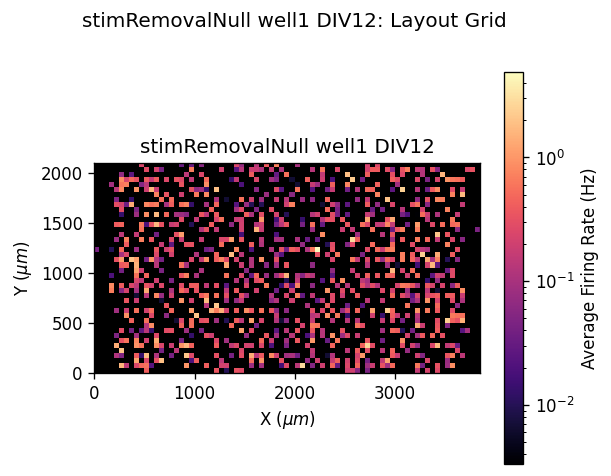

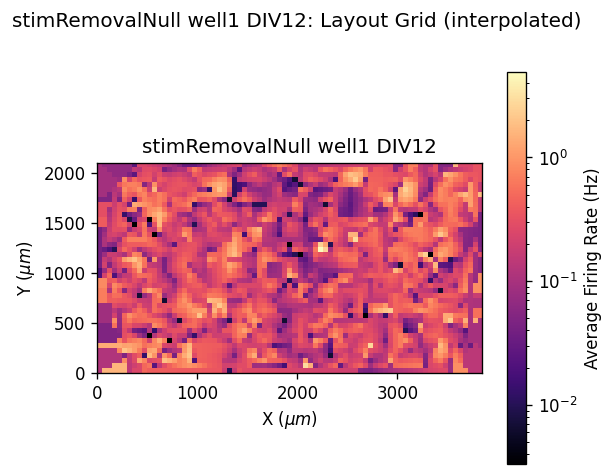

Collected 151406 IFR samples
GMM peak locations (Hz): [4.000e-02 4.163e+01]


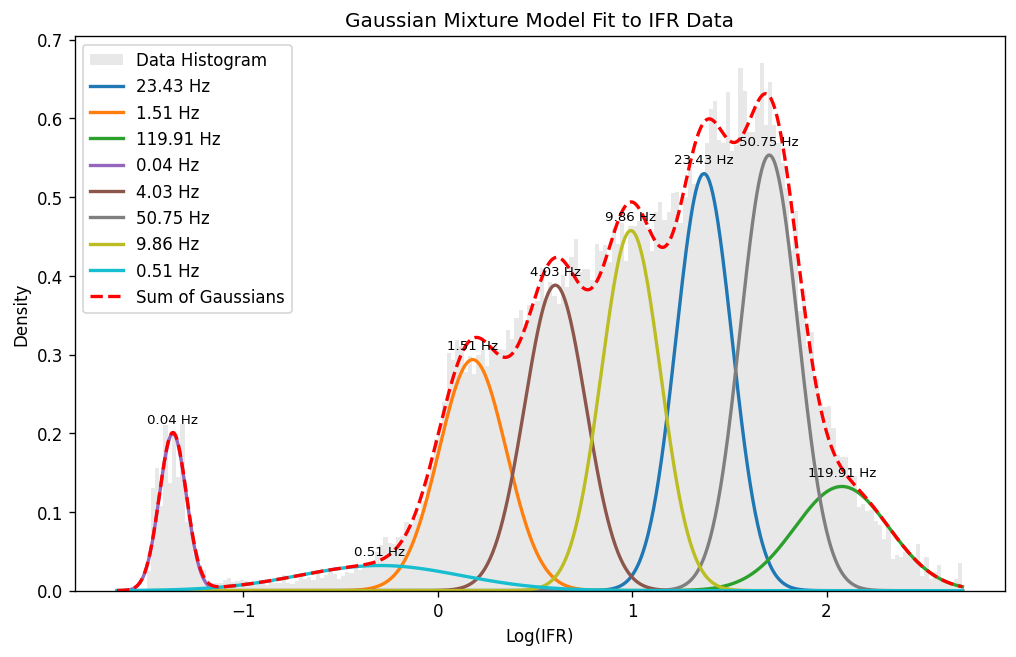

[(<Figure size 1440x960 with 3 Axes>,
  (<Axes: title={'center': 'stimRemovalNull well1 DIV12: IFRAnalyzer | stimRemovalNull well1 DIV12: Log Instantaneous Firing Rate Across Top 300 electrodes'}, xlabel='Time (s)', ylabel='Channel by Firing Frequency Rank'>,
   <Axes: title={'center': 'Histogram of Instantaneous Firing Rates'}, xlabel='Log Instantaneous Firing Rate (Hz)', ylabel='Frequency'>))]

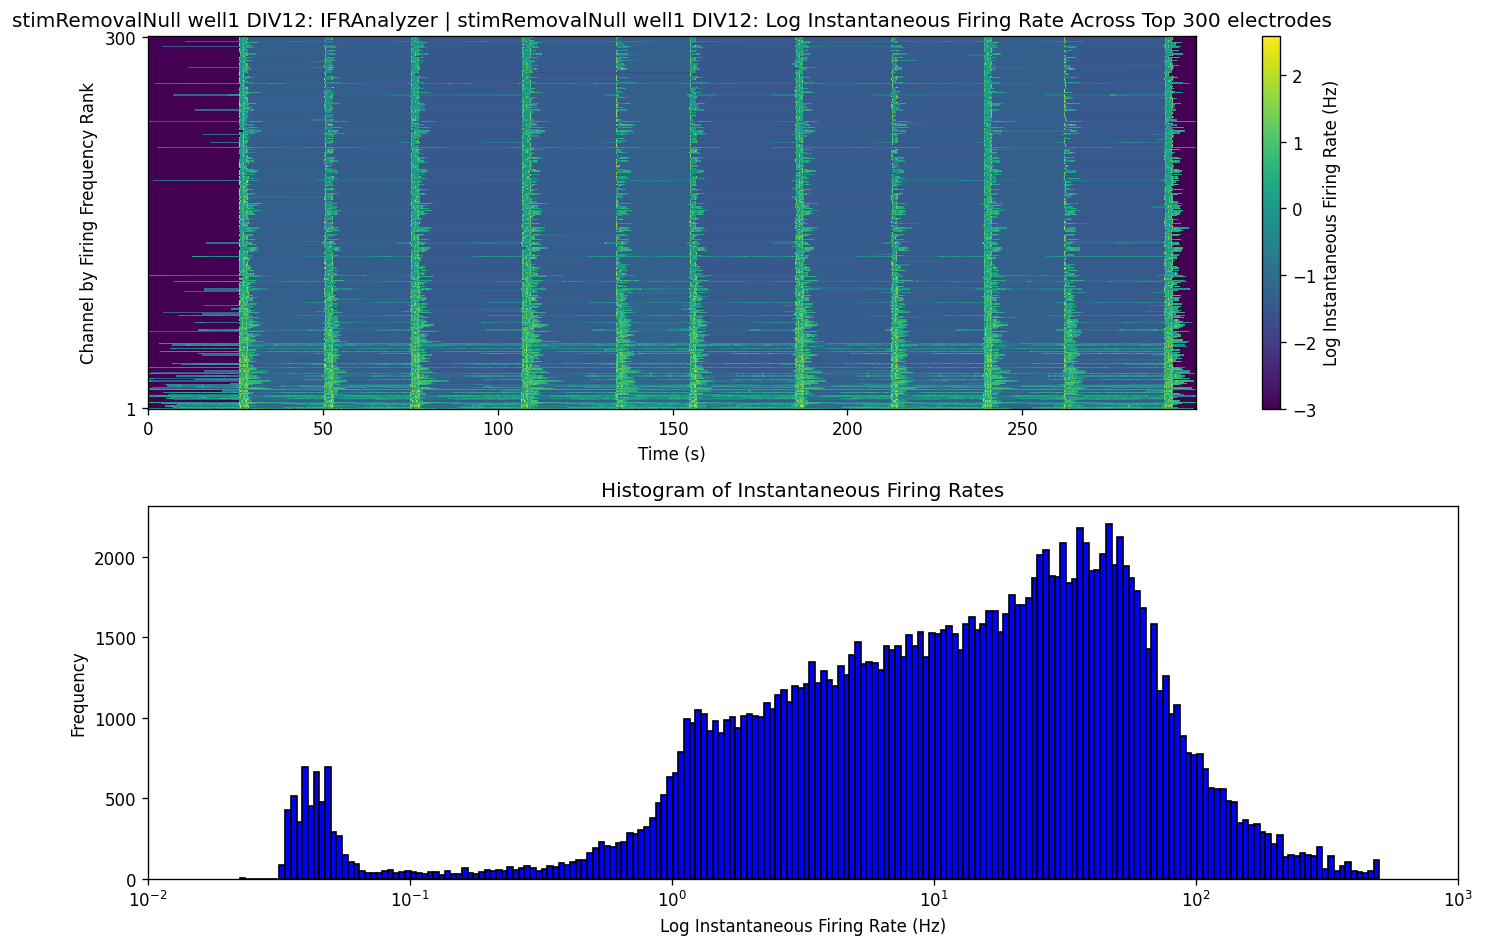

In [5]:
recording_labels = [f"stimRemovalNull well{WELL} DIV{DIV}"]

lg = LayoutGridPlotter(ds)
lg.plot_grid_avghz_panel(
    grid_size=50.0,
    ncols=1,
    interpolate=False,
    title=f"stimRemovalNull well{WELL} DIV{DIV}: Layout Grid",
    recording_titles=recording_labels,
)
lg.plot_grid_avghz_panel(
    grid_size=50.0,
    ncols=1,
    interpolate=True,
    title=f"stimRemovalNull well{WELL} DIV{DIV}: Layout Grid (interpolated)",
    recording_titles=recording_labels,
)

ifr_hist_bins = 200
ifr_cfg = IFRConfig(
    log_scale=True,
    overlay_gmm=True,
    ts_bins=200,
    time_grid_hz=200.0,
    max_time_points=2_000,
)
ifr_analyzer = IFRAnalyzer.from_dataset(ds, config=ifr_cfg, selection_prep_config=prep_cfg)
peaks = ifr_analyzer.peaks()

print(f"Collected {peaks.values.size} IFR samples")
if peaks.peaks_hz.size:
    print("GMM peak locations (Hz):", np.round(peaks.peaks_hz, 2))
else:
    print("No IFR peaks detected; consider widening the selection window.")

ifr_analyzer.plot_histogram(hist_bins=ifr_hist_bins, show=True)
ifr_analyzer.plot_timeseries(
    recording_titles=recording_labels,
    title=f"stimRemovalNull well{WELL} DIV{DIV}: IFRAnalyzer",
)


## Build a Shared IFR Matrix

Each selected electrode gets sample-held onto the same time grid using the raw IFR support points. The burst population trace is the pointwise mean across the selected electrodes.


In [6]:
def build_population_ifr(recording, selected_electrodes, grid_hz=50.0, smooth_sigma_sec=0.15):
    ifr_data, per_electrode_mean_hz, _ = calculate_ifr(
        recording.spikes,
        selected_electrodes,
        recording.start_time,
        recording.end_time,
    )

    dt = 1.0 / float(grid_hz)
    time_grid = np.arange(recording.start_time, recording.end_time, dt, dtype=float)

    traces = []
    electrodes = []
    avg_rates = []
    for el in np.asarray(selected_electrodes, dtype=int):
        if int(el) not in ifr_data:
            continue
        times, values = ifr_data[int(el)]
        sample_idx = np.searchsorted(times, time_grid, side="right") - 1
        trace = np.zeros_like(time_grid, dtype=float)
        valid_mask = sample_idx >= 0
        if np.any(valid_mask):
            trace[valid_mask] = values[sample_idx[valid_mask]]
        traces.append(trace)
        electrodes.append(int(el))
        avg_rates.append(float(per_electrode_mean_hz[int(el)]))

    if not traces:
        raise ValueError("No IFR traces were produced for the selected electrodes.")

    ifr_matrix = np.asarray(traces, dtype=float)
    mean_ifr = ifr_matrix.mean(axis=0)
    sigma_bins = max(float(smooth_sigma_sec) * float(grid_hz), 1e-6)
    mean_ifr_smooth = gaussian_filter1d(mean_ifr, sigma=sigma_bins, mode="nearest")

    return {
        "time_grid": time_grid,
        "electrodes": np.asarray(electrodes, dtype=int),
        "ifr_matrix": ifr_matrix,
        "mean_ifr": mean_ifr,
        "mean_ifr_smooth": mean_ifr_smooth,
        "per_electrode_mean_hz": np.asarray(avg_rates, dtype=float),
    }


burst_data = build_population_ifr(
    rec,
    refs,
    grid_hz=IFR_GRID_HZ,
    smooth_sigma_sec=SMOOTH_SIGMA_SEC,
)

time_grid = burst_data["time_grid"]
ifr_matrix = burst_data["ifr_matrix"]
mean_ifr = burst_data["mean_ifr"]
mean_ifr_smooth = burst_data["mean_ifr_smooth"]

def plot_ifr_summary(time_axis, ifr_view, mean_view, mean_smooth_view, heatmap_title, mean_title, mean_log_scale=False):
    positive_ifr = ifr_view[ifr_view > 0]
    if positive_ifr.size == 0:
        raise ValueError("IFR view contains no positive values for log-scale plotting.")

    heatmap_vmin = max(1e-3, float(np.quantile(positive_ifr, 0.01)))
    heatmap_vmax = float(positive_ifr.max())
    heatmap_vmax = max(heatmap_vmax, heatmap_vmin * (1.0 + 1e-6))
    mean_log_floor = max(heatmap_vmin, 1e-3)

    fig = plt.figure(figsize=(14, 8), constrained_layout=True)
    gs = fig.add_gridspec(
        2,
        2,
        height_ratios=[3.0, 1.6],
        width_ratios=[40.0, 1.6],
    )
    ax0 = fig.add_subplot(gs[0, 0])
    ax1 = fig.add_subplot(gs[1, 0], sharex=ax0)
    cax = fig.add_subplot(gs[0, 1])
    fig.add_subplot(gs[1, 1]).axis("off")

    display_ifr = np.clip(ifr_view, heatmap_vmin, heatmap_vmax)
    im = ax0.imshow(
        display_ifr,
        aspect="auto",
        origin="lower",
        extent=[time_axis[0], time_axis[-1], 0.5, ifr_view.shape[0] + 0.5],
        cmap="viridis",
        norm=LogNorm(vmin=heatmap_vmin, vmax=heatmap_vmax),
    )
    ax0.set_ylabel("Selected electrode rank")
    ax0.set_yticks([1, ifr_view.shape[0]])
    ax0.set_title(heatmap_title)

    cbar = fig.colorbar(im, cax=cax)
    cbar.set_label("Instantaneous firing rate (Hz, log scale)")
    cbar.locator = LogLocator(base=10)
    cbar.formatter = LogFormatterMathtext(base=10)
    cbar.update_ticks()

    if mean_log_scale:
        ax1.plot(time_axis, np.clip(mean_view, mean_log_floor, None), color="0.70", lw=1.0, label="Population mean IFR")
        ax1.plot(
            time_axis,
            np.clip(mean_smooth_view, mean_log_floor, None),
            color="black",
            lw=2.0,
            label=f"Smoothed mean IFR (sigma={SMOOTH_SIGMA_SEC:.2f} s)",
        )
        ax1.set_yscale("log")
        ax1.set_ylabel("Hz (log scale)")
    else:
        ax1.plot(time_axis, mean_view, color="0.70", lw=1.0, label="Population mean IFR")
        ax1.plot(
            time_axis,
            mean_smooth_view,
            color="black",
            lw=2.0,
            label=f"Smoothed mean IFR (sigma={SMOOTH_SIGMA_SEC:.2f} s)",
        )
        ax1.set_ylabel("Hz")

    ax1.set_xlabel("Time (s)")
    ax1.set_title(mean_title)
    ax1.legend(loc="upper right")
    ax1.set_xlim(float(time_axis[0]), float(time_axis[-1]))
    plt.show()

print(f"IFR matrix shape: {ifr_matrix.shape}")
print(f"Population mean range: {mean_ifr.min():.3f} to {mean_ifr.max():.3f} Hz")
print(f"Smoothed population mean range: {mean_ifr_smooth.min():.3f} to {mean_ifr_smooth.max():.3f} Hz")
global_positive_ifr = ifr_matrix[ifr_matrix > 0]
global_heatmap_vmin = max(1e-3, float(np.quantile(global_positive_ifr, 0.01)))
global_heatmap_vmax = float(global_positive_ifr.max())
print(f"Global heatmap log scale range: {global_heatmap_vmin:.4f} to {global_heatmap_vmax:.4f} Hz")


IFR matrix shape: (300, 15000)
Population mean range: 0.000 to 31.751 Hz
Smoothed population mean range: 0.005 to 11.209 Hz
Global heatmap log scale range: 0.0333 to 500.0000 Hz


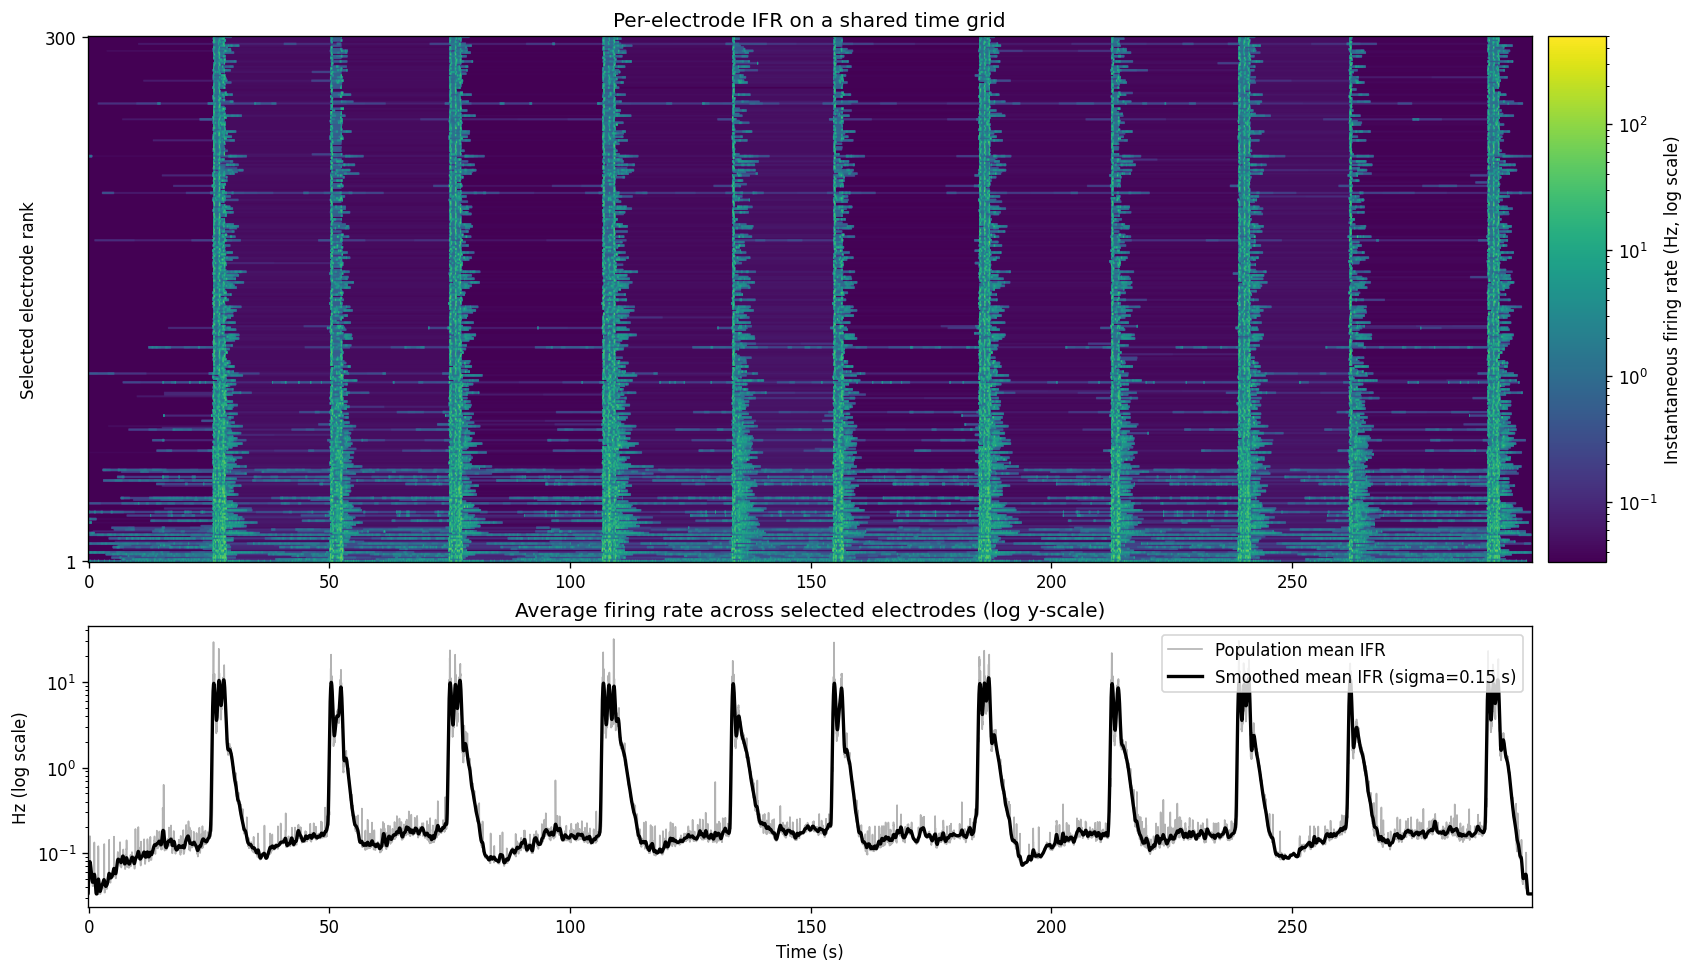

In [7]:

plot_ifr_summary(
    time_grid,
    ifr_matrix,
    mean_ifr,
    mean_ifr_smooth,
    heatmap_title="Per-electrode IFR on a shared time grid",
    mean_title="Average firing rate across selected electrodes (log y-scale)",
    mean_log_scale=True,
)


## Zoom Into a High-Activity Window

The full 300 s trace is useful for context, but a short zoom makes the cross-electrode burst structure easier to inspect.


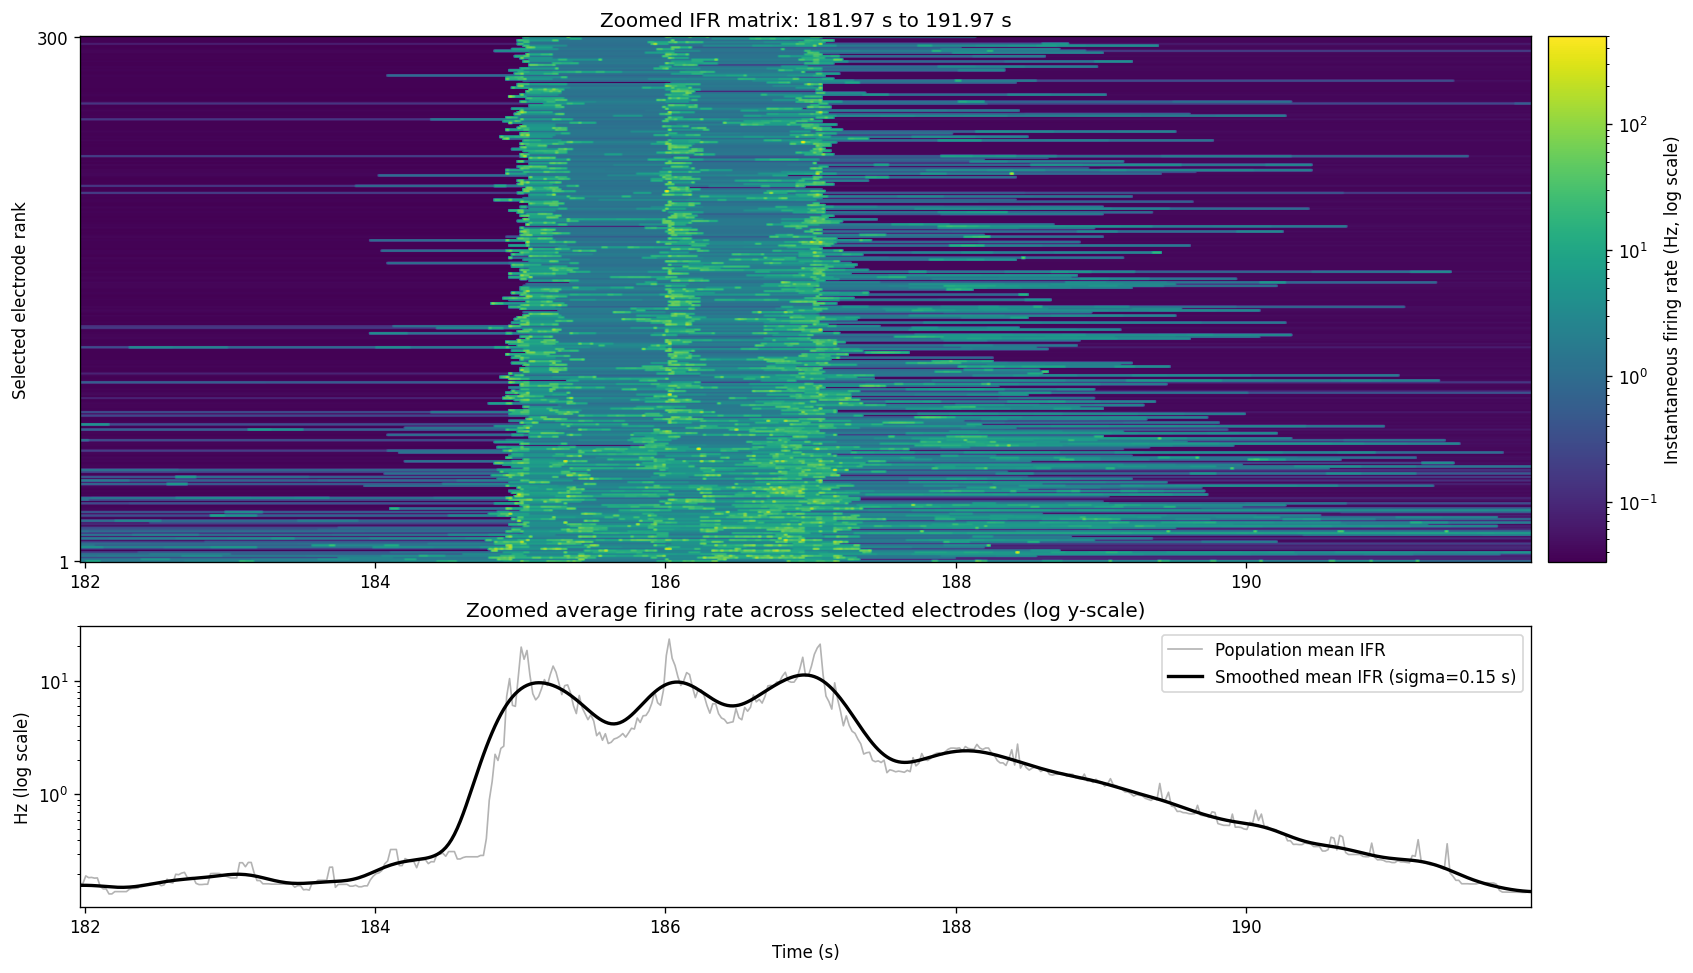

In [8]:
zoom_center_sec = float(time_grid[np.argmax(mean_ifr_smooth)])
zoom_half_width_sec = 5.0
zoom_start = max(time_grid[0], zoom_center_sec - zoom_half_width_sec)
zoom_stop = min(time_grid[-1], zoom_center_sec + zoom_half_width_sec)
zoom_mask = (time_grid >= zoom_start) & (time_grid <= zoom_stop)

plot_ifr_summary(
    time_grid[zoom_mask],
    ifr_matrix[:, zoom_mask],
    mean_ifr[zoom_mask],
    mean_ifr_smooth[zoom_mask],
    heatmap_title=f"Zoomed IFR matrix: {zoom_start:.2f} s to {zoom_stop:.2f} s",
    mean_title="Zoomed average firing rate across selected electrodes (log y-scale)",
    mean_log_scale=True,
)


## Nested Burst and Gamma Anchors

We now separate the problem into two scales:

- a **coarse burst epoch** on the slow population IFR trace
- a **nested gamma anchor** inside that burst using a high-resolution spike-density signal

This avoids treating several slow subpeaks from the same burst as independent events.


In [9]:
def detect_coarse_burst_epochs(time_axis, slow_signal, peak_distance_sec, prominence_quantile, prominence_scale, rel_height=0.20):
    peak_distance_bins = max(1, int(round(peak_distance_sec * IFR_GRID_HZ)))
    prominence_floor = float(np.quantile(slow_signal, prominence_quantile) * prominence_scale)
    raw_peaks, peak_props = find_peaks(
        slow_signal,
        distance=peak_distance_bins,
        prominence=prominence_floor,
    )

    slow_baseline = float(np.quantile(slow_signal, 0.25))
    intervals = []
    for peak_idx in raw_peaks:
        peak_height = float(slow_signal[peak_idx])
        cutoff = slow_baseline + rel_height * (peak_height - slow_baseline)

        left_idx = int(peak_idx)
        while left_idx > 0 and slow_signal[left_idx] > cutoff:
            left_idx -= 1

        right_idx = int(peak_idx)
        while right_idx < len(slow_signal) - 1 and slow_signal[right_idx] > cutoff:
            right_idx += 1

        intervals.append(
            {
                "left_idx": left_idx,
                "right_idx": right_idx,
                "peak_idx": int(peak_idx),
                "peak_height_hz": peak_height,
            }
        )

    intervals = sorted(intervals, key=lambda item: item["left_idx"])
    merged = []
    for interval in intervals:
        if not merged or interval["left_idx"] > merged[-1]["right_idx"]:
            merged.append(
                {
                    "left_idx": interval["left_idx"],
                    "right_idx": interval["right_idx"],
                    "peak_idx": interval["peak_idx"],
                    "peak_height_hz": interval["peak_height_hz"],
                    "subpeak_indices": [interval["peak_idx"]],
                }
            )
        else:
            current = merged[-1]
            current["right_idx"] = max(current["right_idx"], interval["right_idx"])
            current["subpeak_indices"].append(interval["peak_idx"])
            if interval["peak_height_hz"] > current["peak_height_hz"]:
                current["peak_idx"] = interval["peak_idx"]
                current["peak_height_hz"] = interval["peak_height_hz"]

    coarse_epochs = pd.DataFrame(
        [
            {
                "event_idx": event_idx,
                "start_idx": item["left_idx"],
                "end_idx": item["right_idx"],
                "start_time_s": float(time_axis[item["left_idx"]]),
                "end_time_s": float(time_axis[item["right_idx"]]),
                "coarse_peak_idx": item["peak_idx"],
                "coarse_peak_time_s": float(time_axis[item["peak_idx"]]),
                "coarse_peak_hz": float(item["peak_height_hz"]),
                "subpeak_count": len(item["subpeak_indices"]),
            }
            for event_idx, item in enumerate(merged)
        ]
    )
    return coarse_epochs, raw_peaks, peak_props


def build_highres_traces(recording, selected_electrodes, bin_ms=1.0, smooth_sigma_ms=3.0):
    dt = float(bin_ms) / 1000.0
    bin_edges = np.arange(recording.start_time, recording.end_time + dt, dt)
    time_centers = bin_edges[:-1] + 0.5 * dt

    spike_times = np.asarray(recording.spikes["time"], dtype=float)
    spike_electrodes = np.asarray(recording.spikes["electrode"], dtype=int)

    per_electrode_rate_hz = []
    spikes_by_electrode = {}
    for electrode in np.asarray(selected_electrodes, dtype=int):
        electrode_times = np.sort(
            spike_times[
                (spike_electrodes == int(electrode))
                & (spike_times >= recording.start_time)
                & (spike_times <= recording.end_time)
            ]
        )
        spikes_by_electrode[int(electrode)] = electrode_times

        counts, _ = np.histogram(electrode_times, bins=bin_edges)
        rate_hz = counts.astype(float) / dt
        per_electrode_rate_hz.append(
            gaussian_filter1d(rate_hz, sigma=float(smooth_sigma_ms) / float(bin_ms), mode="nearest")
        )

    per_electrode_rate_hz = np.asarray(per_electrode_rate_hz, dtype=float)
    population_rate_hz = per_electrode_rate_hz.mean(axis=0)

    return {
        "bin_edges_s": bin_edges,
        "time_centers_s": time_centers,
        "electrodes": np.asarray(selected_electrodes, dtype=int),
        "per_electrode_rate_hz": per_electrode_rate_hz,
        "population_rate_hz": population_rate_hz,
        "spikes_by_electrode": spikes_by_electrode,
    }


def choose_nested_gamma_anchors(
    time_centers,
    population_rate_hz,
    coarse_start_s,
    coarse_end_s,
    coarse_event_idx,
    coarse_rel_height,
    bin_ms,
    search_ms,
    search_to_epoch_end,
    min_distance_ms,
    prominence_frac,
    prominence_abs_floor,
    keep_height_frac,
    baseline_floor,
):
    epoch_mask = (time_centers >= coarse_start_s) & (time_centers <= coarse_end_s)
    epoch_time = time_centers[epoch_mask]
    epoch_signal = population_rate_hz[epoch_mask]

    if epoch_signal.size == 0:
        nearest_idx = int(np.argmin(np.abs(time_centers - 0.5 * (float(coarse_start_s) + float(coarse_end_s)))))
        fallback_time_s = float(time_centers[nearest_idx])
        fallback_height_hz = float(population_rate_hz[nearest_idx])
        return [{
            "event_idx": int(coarse_event_idx),
            "gamma_peak_rank": 0,
            "onset_time_s": fallback_time_s,
            "anchor_time_s": fallback_time_s,
            "anchor_height_hz": fallback_height_hz,
            "gamma_anchor_delay_ms": 0.0,
            "n_local_peaks": 0,
            "n_passing_prominence": 0,
            "n_kept_gamma_peaks": 1,
            "onset_threshold_hz": fallback_height_hz,
            "search_stop_s": fallback_time_s,
            "prominence_floor_hz": float(prominence_abs_floor),
            "keep_height_floor_hz": fallback_height_hz,
        }]

    local_baseline = max(float(np.quantile(epoch_signal, 0.10)), float(baseline_floor))
    local_peak = float(epoch_signal.max())
    onset_threshold = local_baseline + coarse_rel_height * (local_peak - local_baseline)

    onset_candidates = np.flatnonzero(epoch_signal >= onset_threshold)
    onset_idx = int(onset_candidates[0]) if onset_candidates.size else int(np.argmax(epoch_signal))
    onset_time_s = float(epoch_time[onset_idx])

    if bool(search_to_epoch_end):
        search_stop_s = float(coarse_end_s)
    else:
        search_stop_s = min(float(coarse_end_s), onset_time_s + float(search_ms) / 1000.0)

    lead_mask = (epoch_time >= onset_time_s) & (epoch_time <= search_stop_s)
    lead_time = epoch_time[lead_mask]
    lead_signal = epoch_signal[lead_mask]

    if lead_signal.size == 0:
        fallback_idx = int(np.argmax(epoch_signal))
        fallback_time_s = float(epoch_time[fallback_idx])
        fallback_height_hz = float(epoch_signal[fallback_idx])
        return [{
            "event_idx": int(coarse_event_idx),
            "gamma_peak_rank": 0,
            "onset_time_s": onset_time_s,
            "anchor_time_s": fallback_time_s,
            "anchor_height_hz": fallback_height_hz,
            "gamma_anchor_delay_ms": (fallback_time_s - onset_time_s) * 1000.0,
            "n_local_peaks": 0,
            "n_passing_prominence": 0,
            "n_kept_gamma_peaks": 1,
            "onset_threshold_hz": onset_threshold,
            "search_stop_s": search_stop_s,
            "prominence_floor_hz": float(prominence_abs_floor),
            "keep_height_floor_hz": fallback_height_hz,
        }]

    min_distance_bins = max(1, int(round(float(min_distance_ms) / float(bin_ms))))
    prominence_floor = max(float(prominence_frac) * max(lead_signal.max() - local_baseline, 0.0), float(prominence_abs_floor))

    all_peak_idx, _ = find_peaks(lead_signal, distance=min_distance_bins)
    if all_peak_idx.size == 0:
        fallback_idx = int(np.argmax(lead_signal))
        all_peak_idx = np.array([fallback_idx], dtype=int)
        all_prominences = np.array([max(float(lead_signal[fallback_idx] - local_baseline), 0.0)], dtype=float)
    else:
        all_prominences = peak_prominences(lead_signal, all_peak_idx)[0]

    all_peak_heights = np.asarray(lead_signal[all_peak_idx], dtype=float)
    passes_prominence = all_prominences >= prominence_floor

    if np.any(passes_prominence):
        gamma_peak_idx = all_peak_idx[passes_prominence]
        gamma_prominences = all_prominences[passes_prominence]
        gamma_peak_heights = all_peak_heights[passes_prominence]
    else:
        fallback_pick = int(np.argmax(all_peak_heights))
        gamma_peak_idx = np.array([int(all_peak_idx[fallback_pick])], dtype=int)
        gamma_prominences = np.array([float(all_prominences[fallback_pick])], dtype=float)
        gamma_peak_heights = np.array([float(all_peak_heights[fallback_pick])], dtype=float)

    keep_height_floor = local_baseline + float(keep_height_frac) * max(local_peak - local_baseline, 0.0)
    keep_height_mask = gamma_peak_heights >= keep_height_floor
    keep_prom_mask = gamma_prominences >= 0.5 * float(gamma_prominences.max())
    keep_mask = keep_height_mask | keep_prom_mask
    kept_idx = gamma_peak_idx[keep_mask] if np.any(keep_mask) else gamma_peak_idx

    anchor_records = []
    for anchor_rank, local_idx in enumerate(np.sort(kept_idx)):
        anchor_time_s = float(lead_time[int(local_idx)])
        anchor_height_hz = float(lead_signal[int(local_idx)])
        anchor_records.append(
            {
                "event_idx": int(coarse_event_idx),
                "gamma_peak_rank": int(anchor_rank),
                "onset_time_s": onset_time_s,
                "anchor_time_s": anchor_time_s,
                "anchor_height_hz": anchor_height_hz,
                "gamma_anchor_delay_ms": (anchor_time_s - onset_time_s) * 1000.0,
                "n_local_peaks": int(all_peak_idx.size),
                "n_passing_prominence": int(passes_prominence.sum()),
                "n_kept_gamma_peaks": int(len(kept_idx)),
                "onset_threshold_hz": onset_threshold,
                "search_stop_s": search_stop_s,
                "prominence_floor_hz": float(prominence_floor),
                "keep_height_floor_hz": float(keep_height_floor),
            }
        )
    return anchor_records


coarse_epochs, raw_peak_idx, raw_peak_props = detect_coarse_burst_epochs(
    time_grid,
    mean_ifr_smooth,
    peak_distance_sec=BURST_MIN_DISTANCE_SEC,
    prominence_quantile=BURST_PROMINENCE_QUANTILE,
    prominence_scale=BURST_PROMINENCE_SCALE,
    rel_height=COARSE_EPOCH_REL_HEIGHT,
)

highres_data = build_highres_traces(
    rec,
    refs,
    bin_ms=HIGHRES_BIN_MS,
    smooth_sigma_ms=HIGHRES_SMOOTH_SIGMA_MS,
)

global_gamma_baseline = float(np.quantile(highres_data["population_rate_hz"], 0.25))
nested_anchor_records = []
for row in coarse_epochs.itertuples(index=False):
    anchor_infos = choose_nested_gamma_anchors(
        highres_data["time_centers_s"],
        highres_data["population_rate_hz"],
        coarse_start_s=row.start_time_s,
        coarse_end_s=row.end_time_s,
        coarse_event_idx=row.event_idx,
        coarse_rel_height=COARSE_EPOCH_REL_HEIGHT,
        bin_ms=HIGHRES_BIN_MS,
        search_ms=GAMMA_SEARCH_MS,
        search_to_epoch_end=GAMMA_SEARCH_TO_EPOCH_END,
        min_distance_ms=GAMMA_MIN_DISTANCE_MS,
        prominence_frac=GAMMA_PROMINENCE_FRAC,
        prominence_abs_floor=GAMMA_PROMINENCE_ABS_FLOOR,
        keep_height_frac=GAMMA_KEEP_HEIGHT_FRAC,
        baseline_floor=global_gamma_baseline,
    )
    for anchor_info in anchor_infos:
        nested_anchor_records.append(
            {
                "coarse_event_idx": int(row.event_idx),
                "start_time_s": float(row.start_time_s),
                "end_time_s": float(row.end_time_s),
                "coarse_peak_time_s": float(row.coarse_peak_time_s),
                "coarse_peak_hz": float(row.coarse_peak_hz),
                "subpeak_count": int(row.subpeak_count),
                **anchor_info,
            }
        )

nested_anchors = pd.DataFrame(nested_anchor_records)

print(f"Raw slow peaks: {len(raw_peak_idx)}")
print(f"Merged coarse burst epochs: {len(coarse_epochs)}")
print(f"Nested gamma anchors: {len(nested_anchors)}")
nested_anchors[[
    "coarse_event_idx",
    "gamma_peak_rank",
    "start_time_s",
    "end_time_s",
    "coarse_peak_time_s",
    "onset_time_s",
    "anchor_time_s",
    "gamma_anchor_delay_ms",
    "subpeak_count",
    "n_local_peaks",
    "n_passing_prominence",
    "n_kept_gamma_peaks",
    "prominence_floor_hz",
    "keep_height_floor_hz",
]].head(10)


Raw slow peaks: 26
Merged coarse burst epochs: 11
Nested gamma anchors: 26


,coarse_event_idx,gamma_peak_rank,start_time_s,end_time_s,coarse_peak_time_s,onset_time_s,anchor_time_s,gamma_anchor_delay_ms,subpeak_count,n_local_peaks,n_passing_prominence,n_kept_gamma_peaks,prominence_floor_hz,keep_height_floor_hz
0,0,0,25.6063,28.7463,28.0263,25.7648,25.9008,136.0,2,54,21,2,4.149575,27.661189
1,0,1,25.6063,28.7463,28.0263,25.7648,26.9928,1228.0,2,54,21,2,4.149575,27.661189
2,1,0,49.9663,52.8863,50.3863,50.1658,50.2648,99.0,2,47,23,2,3.702294,24.363481
3,1,1,49.9663,52.8863,50.3863,50.1658,50.3288,163.0,2,47,23,2,3.702294,24.363481
4,2,0,74.6863,77.6863,77.1063,74.8668,75.0268,160.0,2,52,25,4,3.270066,22.039859
5,2,1,74.6863,77.6863,77.1063,74.8668,75.1948,328.0,2,52,25,4,3.270066,22.039859
6,2,2,74.6863,77.6863,77.1063,74.8668,76.0968,1230.0,2,52,25,4,3.270066,22.039859
7,2,3,74.6863,77.6863,77.1063,74.8668,77.2278,2361.0,2,52,25,4,3.270066,22.039859
8,3,0,106.5263,110.6063,106.9263,106.7218,106.8668,145.0,3,68,20,2,4.342623,28.739403
9,3,1,106.5263,110.6063,106.9263,106.7218,109.0498,2328.0,3,68,20,2,4.342623,28.739403


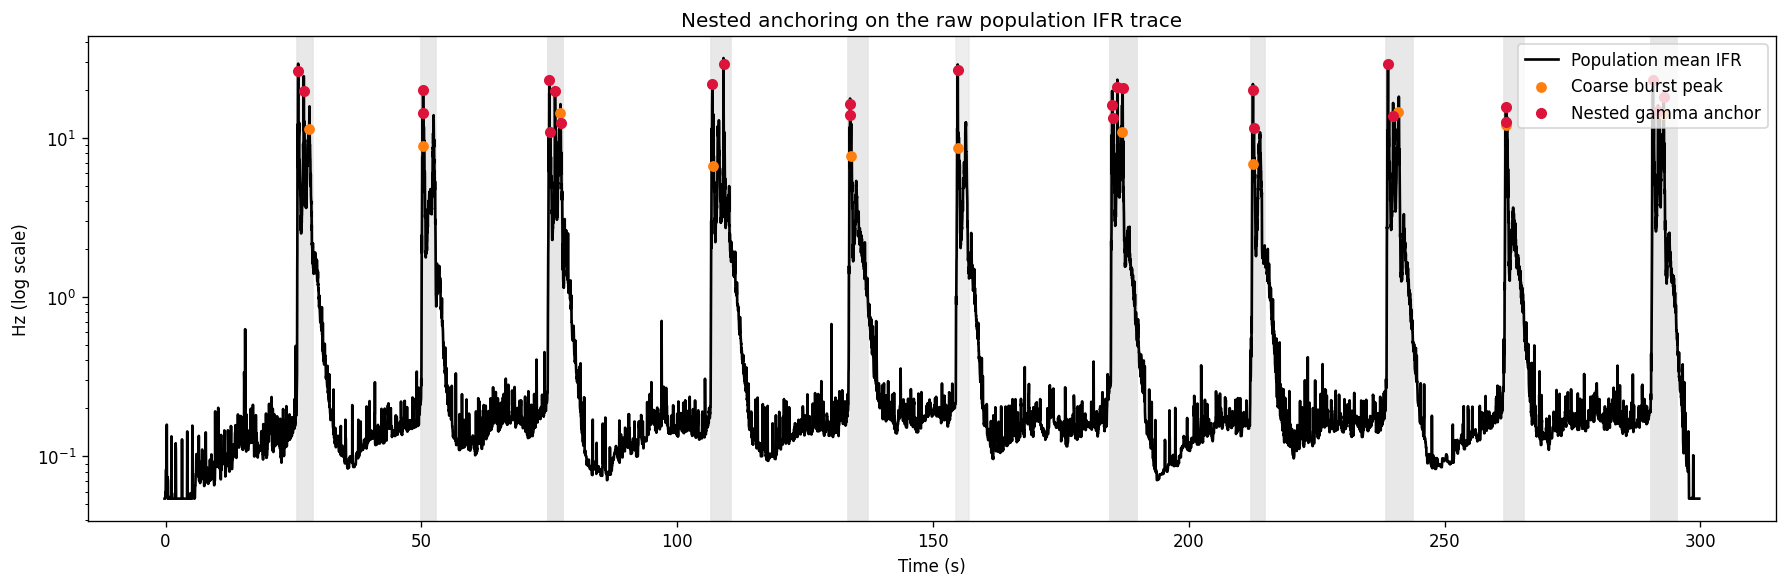

,coarse_event_idx,start_time_s,end_time_s,coarse_peak_time_s,onset_time_s,anchor_time_s,gamma_anchor_delay_ms,subpeak_count,n_local_peaks,n_passing_prominence,n_kept_gamma_peaks,prominence_floor_hz,keep_height_floor_hz
0,0,25.606,28.746,28.026,25.765,25.901,136.0,2,54,21,2,4.150,27.661
1,0,25.606,28.746,28.026,25.765,26.993,1228.0,2,54,21,2,4.150,27.661
2,1,49.966,52.886,50.386,50.166,50.265,99.0,2,47,23,2,3.702,24.363
3,1,49.966,52.886,50.386,50.166,50.329,163.0,2,47,23,2,3.702,24.363
4,2,74.686,77.686,77.106,74.867,75.027,160.0,2,52,25,4,3.270,22.040
5,2,74.686,77.686,77.106,74.867,75.195,328.0,2,52,25,4,3.270,22.040
6,2,74.686,77.686,77.106,74.867,76.097,1230.0,2,52,25,4,3.270,22.040
7,2,74.686,77.686,77.106,74.867,77.228,2361.0,2,52,25,4,3.270,22.040
8,3,106.526,110.606,106.926,106.722,106.867,145.0,3,68,20,2,4.343,28.739
9,3,106.526,110.606,106.926,106.722,109.050,2328.0,3,68,20,2,4.343,28.739


In [10]:
slow_positive = mean_ifr[mean_ifr > 0]
slow_floor = max(1e-2, float(np.quantile(slow_positive, 0.02)))

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(time_grid, np.clip(mean_ifr, slow_floor, None), color="black", lw=1.6, label="Population mean IFR")

for row in nested_anchors.itertuples(index=False):
    ax.axvspan(row.start_time_s, row.end_time_s, color="0.90", alpha=0.65)

ax.scatter(
    coarse_epochs["coarse_peak_time_s"],
    np.clip(np.interp(coarse_epochs["coarse_peak_time_s"], time_grid, mean_ifr), slow_floor, None),
    color="tab:orange",
    s=30,
    zorder=3,
    label="Coarse burst peak",
)
ax.scatter(
    nested_anchors["anchor_time_s"],
    np.clip(np.interp(nested_anchors["anchor_time_s"], time_grid, mean_ifr), slow_floor, None),
    color="crimson",
    s=32,
    zorder=4,
    label="Nested gamma anchor",
)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Hz (log scale)")
ax.set_yscale("log")
ax.set_title("Nested anchoring on the raw population IFR trace")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

nested_anchors[[
    "coarse_event_idx",
    "start_time_s",
    "end_time_s",
    "coarse_peak_time_s",
    "onset_time_s",
    "anchor_time_s",
    "gamma_anchor_delay_ms",
    "subpeak_count",
    "n_local_peaks",
    "n_passing_prominence",
    "n_kept_gamma_peaks",
    "prominence_floor_hz",
    "keep_height_floor_hz",
]].round(3)


## Gamma-Centered Windows

Keep the same globally parameterised gamma windows that the burst notebook uses. These windows define the spike subset for the TE prototype.

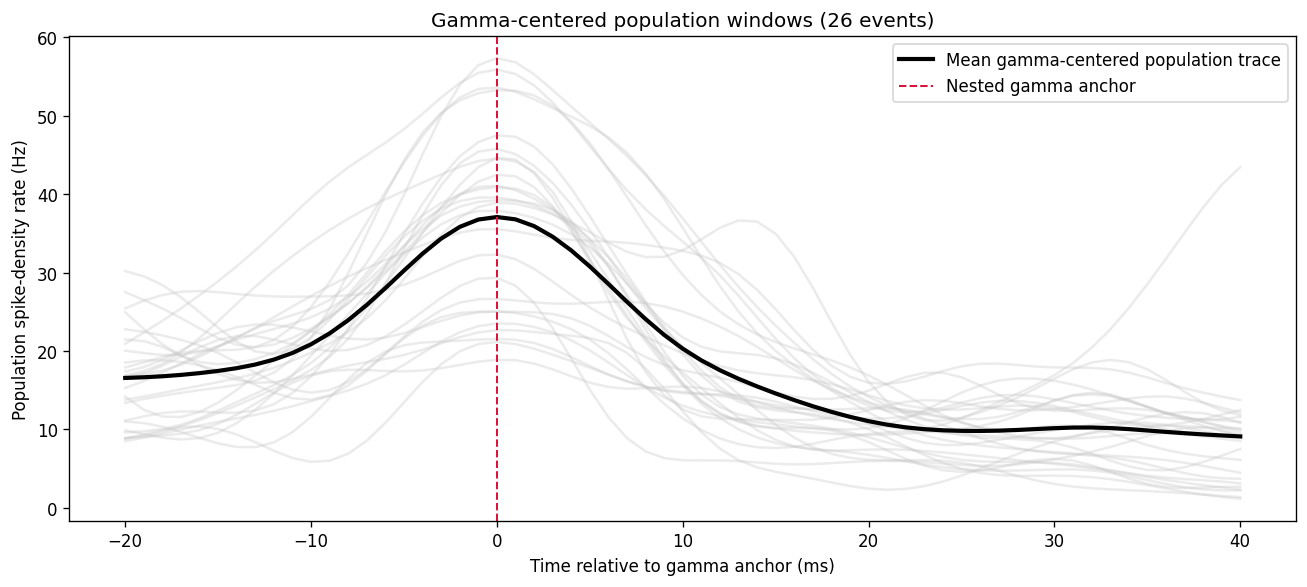

Valid gamma-centered windows: 26
Aligned tensor shape: (26, 300, 61)


,coarse_event_idx,gamma_peak_rank,anchor_time_s,window_start_s,window_stop_s,gamma_anchor_delay_ms
0,0,0,25.9008,25.8808,25.9408,136.0
1,0,1,26.9928,26.9728,27.0328,1228.0
2,1,0,50.2648,50.2448,50.3048,99.0
3,1,1,50.3288,50.3088,50.3688,163.0
4,2,0,75.0268,75.0068,75.0668,160.0
5,2,1,75.1948,75.1748,75.2348,328.0
6,2,2,76.0968,76.0768,76.1368,1230.0
7,2,3,77.2278,77.2078,77.2678,2361.0
8,3,0,106.8668,106.8468,106.9068,145.0
9,3,1,109.0498,109.0298,109.0898,2328.0


In [11]:
pre_bins = int(round(ALIGN_PRE_MS / HIGHRES_BIN_MS))
post_bins = int(round(ALIGN_POST_MS / HIGHRES_BIN_MS))
relative_time_ms = (np.arange(-pre_bins, post_bins + 1) * HIGHRES_BIN_MS).astype(float)

time_centers_highres = highres_data["time_centers_s"]
population_rate_highres = highres_data["population_rate_hz"]
per_electrode_rate_highres = highres_data["per_electrode_rate_hz"]
selected_electrodes = highres_data["electrodes"]
spikes_by_electrode = highres_data["spikes_by_electrode"]

time_bin_half_width_s = 0.5 * float(HIGHRES_BIN_MS) / 1000.0
time_edges_highres = np.concatenate(
    ([float(time_centers_highres[0]) - time_bin_half_width_s], time_centers_highres + time_bin_half_width_s)
)
spike_presence_highres = []
for electrode in selected_electrodes:
    electrode_spike_times = np.asarray(spikes_by_electrode[int(electrode)], dtype=float)
    spike_counts_highres, _ = np.histogram(electrode_spike_times, bins=time_edges_highres)
    spike_presence_highres.append(spike_counts_highres > 0)
spike_presence_highres = np.asarray(spike_presence_highres, dtype=bool)

population_windows = []
aligned_tensor = []
aligned_spike_tensor = []
valid_nested_anchor_rows = []
for row in nested_anchors.itertuples(index=False):
    anchor_idx = int(np.argmin(np.abs(time_centers_highres - row.anchor_time_s)))
    window_start = anchor_idx - pre_bins
    window_stop = anchor_idx + post_bins + 1
    if window_start < 0 or window_stop > len(time_centers_highres):
        continue

    population_windows.append(population_rate_highres[window_start:window_stop])
    aligned_tensor.append(per_electrode_rate_highres[:, window_start:window_stop])
    aligned_spike_tensor.append(spike_presence_highres[:, window_start:window_stop])

    record = row._asdict()
    record.update(
        {
            "window_start_idx": int(window_start),
            "window_stop_idx": int(window_stop - 1),
            "window_start_s": float(time_centers_highres[window_start]),
            "window_stop_s": float(time_centers_highres[window_stop - 1]),
        }
    )
    valid_nested_anchor_rows.append(record)

population_windows = np.asarray(population_windows, dtype=float)
aligned_tensor = np.asarray(aligned_tensor, dtype=float)
aligned_spike_tensor = np.asarray(aligned_spike_tensor, dtype=bool)
valid_nested_anchors = pd.DataFrame(valid_nested_anchor_rows)

if valid_nested_anchors.empty:
    raise ValueError("No valid gamma-centered windows were available for the TE notebook.")

fig, ax = plt.subplots(figsize=(11, 5))
for row in population_windows:
    ax.plot(relative_time_ms, row, color="0.78", alpha=0.35)
ax.plot(relative_time_ms, population_windows.mean(axis=0), color="black", lw=2.5, label="Mean gamma-centered population trace")
ax.axvline(0.0, color="crimson", ls="--", lw=1.2, label="Nested gamma anchor")
ax.set_xlabel("Time relative to gamma anchor (ms)")
ax.set_ylabel("Population spike-density rate (Hz)")
ax.set_title(f"Gamma-centered population windows ({len(valid_nested_anchors)} events)")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

print(f"Valid gamma-centered windows: {len(valid_nested_anchors)}")
print(f"Aligned tensor shape: {aligned_tensor.shape}")
valid_nested_anchors[[
    "coarse_event_idx",
    "gamma_peak_rank",
    "anchor_time_s",
    "window_start_s",
    "window_stop_s",
    "gamma_anchor_delay_ms",
]].head(10)

## Gamma-Restricted Spikes and X-Band Nodes

Restrict spikes to the union of valid gamma windows, merge overlapping windows so spikes are not double-counted, and aggregate the retained spikes into signed `x`-position bands.

Merged gamma windows: 24
Gamma-restricted spikes across active x-bands: 8,658
Dropped x-bands (< 200 spikes): none


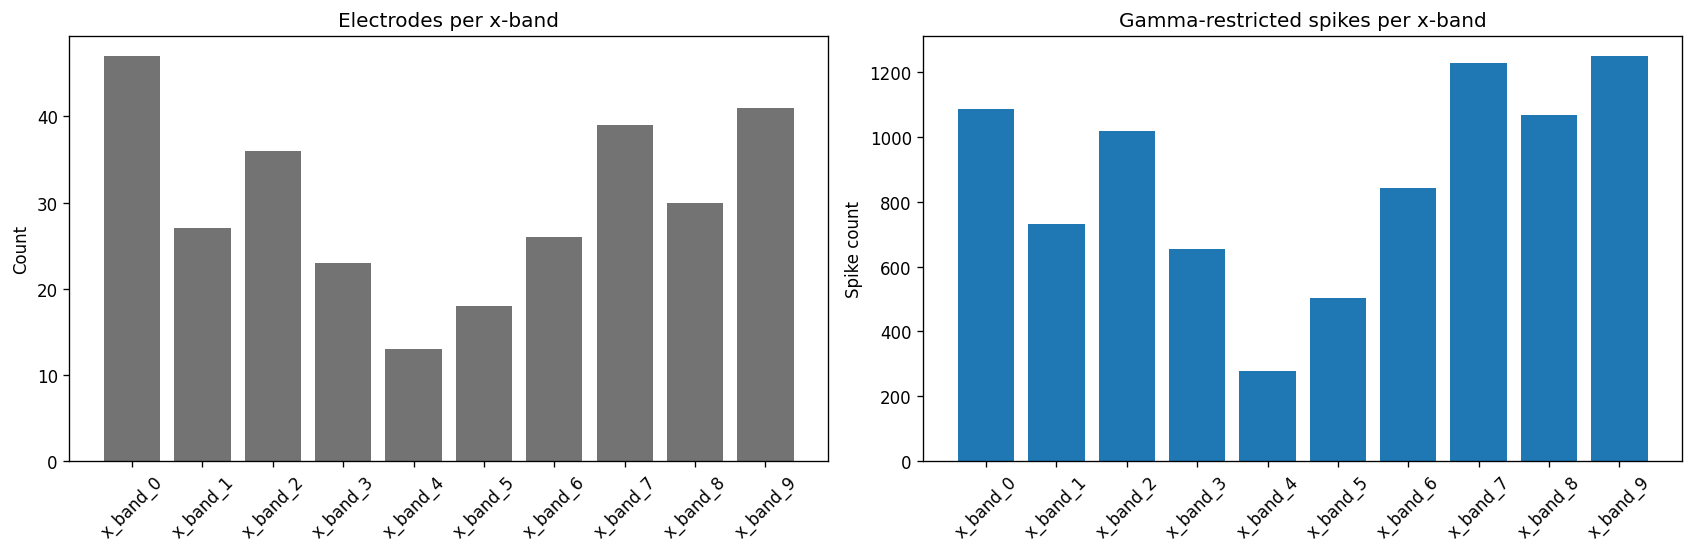

,node_label,band_idx,x_start_um,x_stop_um,x_center_um,y_center_um,n_electrodes,n_gamma_spikes,dropped
0,x_band_0,0,192.5,542.5,385.372340,971.436170,47,1086,False
1,x_band_1,1,542.5,892.5,716.203704,1160.833333,27,730,False
2,x_band_2,2,892.5,1242.5,1084.027778,947.916667,36,1020,False
3,x_band_3,3,1242.5,1592.5,1437.282609,974.673913,23,654,False
4,x_band_4,4,1592.5,1942.5,1727.115385,1016.346154,13,276,False
5,x_band_5,5,1942.5,2292.5,2133.055556,1024.722222,18,504,False
6,x_band_6,6,2292.5,2642.5,2467.500000,915.384615,26,842,False
7,x_band_7,7,2642.5,2992.5,2863.269231,1124.935897,39,1228,False
8,x_band_8,8,2992.5,3342.5,3180.333333,1065.166667,30,1068,False
9,x_band_9,9,3342.5,3692.5,3531.158537,1110.182927,41,1250,False


In [12]:
def merge_time_windows(windows_df):
    if windows_df.empty:
        return pd.DataFrame(columns=["start_s", "stop_s"])

    rows = (
        windows_df[["window_start_s", "window_stop_s"]]
        .rename(columns={"window_start_s": "start_s", "window_stop_s": "stop_s"})
        .sort_values("start_s")
        .to_dict("records")
    )
    merged = []
    for row in rows:
        start_s = float(row["start_s"])
        stop_s = float(row["stop_s"])
        if not merged or start_s > merged[-1]["stop_s"]:
            merged.append({"start_s": start_s, "stop_s": stop_s})
        else:
            merged[-1]["stop_s"] = max(float(merged[-1]["stop_s"]), stop_s)
    return pd.DataFrame(merged)


def restrict_spike_times_to_windows(spike_times_s, windows_df):
    spike_times_s = np.asarray(spike_times_s, dtype=float)
    if spike_times_s.size == 0 or windows_df.empty:
        return np.array([], dtype=float)

    keep_mask = np.zeros(spike_times_s.shape, dtype=bool)
    for row in windows_df.itertuples(index=False):
        keep_mask |= (spike_times_s >= float(row.start_s)) & (spike_times_s <= float(row.stop_s))
    return np.sort(spike_times_s[keep_mask])


def make_strictly_increasing_event_train(spike_times_s, eps_s):
    spike_times_s = np.asarray(spike_times_s, dtype=float).copy()
    if spike_times_s.size <= 1:
        return spike_times_s
    for idx in range(1, spike_times_s.size):
        if spike_times_s[idx] <= spike_times_s[idx - 1]:
            spike_times_s[idx] = spike_times_s[idx - 1] + float(eps_s)
    return spike_times_s


if TE_EVENT_SCOPE != "gamma":
    raise ValueError("This notebook currently implements the gamma-only TE prototype.")
if TE_NODE_MODE != "x_bands":
    raise ValueError("This notebook currently implements only TE_NODE_MODE='x_bands'.")

gamma_windows = merge_time_windows(valid_nested_anchors)
layout_df = pd.DataFrame(rec.layout).drop_duplicates("electrode").copy()
layout_df = layout_df[layout_df["electrode"].isin(selected_electrodes)].copy()
layout_df = layout_df.set_index("electrode").loc[selected_electrodes].reset_index()

x_min = float(layout_df["x"].min())
x_max = float(layout_df["x"].max())
if not np.isfinite(x_min) or not np.isfinite(x_max):
    raise ValueError("Selected-electrode layout is missing finite x coordinates.")
if np.isclose(x_min, x_max):
    x_max = x_min + 1.0

x_edges = np.linspace(x_min, x_max, int(TE_X_BAND_COUNT) + 1)
layout_df["x_band"] = pd.cut(
    layout_df["x"],
    bins=x_edges,
    labels=False,
    include_lowest=True,
    duplicates="drop",
).astype(int)
layout_df["x_centered_um"] = layout_df["x"] - float(layout_df["x"].mean())

te_node_rows = []
te_node_spike_times = {}
all_gamma_spikes = 0
for band_idx in range(int(layout_df["x_band"].max()) + 1):
    band_electrodes = layout_df.loc[layout_df["x_band"] == band_idx, "electrode"].to_numpy(dtype=int)
    band_x = layout_df.loc[layout_df["x_band"] == band_idx, "x"].to_numpy(dtype=float)
    band_y = layout_df.loc[layout_df["x_band"] == band_idx, "y"].to_numpy(dtype=float)

    restricted_trains = [restrict_spike_times_to_windows(spikes_by_electrode[int(el)], gamma_windows) for el in band_electrodes]
    raw_spikes = np.concatenate([arr for arr in restricted_trains if arr.size > 0]).astype(float) if restricted_trains else np.array([], dtype=float)
    raw_spikes = np.sort(raw_spikes)
    adjusted_spikes = make_strictly_increasing_event_train(raw_spikes, eps_s=TE_DUPLICATE_EPS_SEC)
    all_gamma_spikes += int(adjusted_spikes.size)

    node_label = f"x_band_{band_idx}"
    te_node_spike_times[node_label] = adjusted_spikes
    te_node_rows.append(
        {
            "node_label": node_label,
            "band_idx": int(band_idx),
            "x_start_um": float(x_edges[band_idx]),
            "x_stop_um": float(x_edges[band_idx + 1]),
            "x_center_um": float(np.mean(band_x)) if band_x.size else float(0.5 * (x_edges[band_idx] + x_edges[band_idx + 1])),
            "y_center_um": float(np.mean(band_y)) if band_y.size else np.nan,
            "n_electrodes": int(band_electrodes.size),
            "n_gamma_spikes": int(adjusted_spikes.size),
            "dropped": bool(adjusted_spikes.size < int(TE_MIN_SPIKES_PER_NODE)),
        }
    )

te_node_summary = pd.DataFrame(te_node_rows).sort_values("band_idx").reset_index(drop=True)
te_active_node_summary = te_node_summary.loc[~te_node_summary["dropped"]].copy().reset_index(drop=True)
te_active_node_labels = te_active_node_summary["node_label"].tolist()

dropped_nodes = te_node_summary.loc[te_node_summary["dropped"], "node_label"].tolist()
print(f"Merged gamma windows: {len(gamma_windows)}")
print(f"Gamma-restricted spikes across active x-bands: {sum(int(te_node_spike_times[label].size) for label in te_active_node_labels):,}")
print(f"Dropped x-bands (< {TE_MIN_SPIKES_PER_NODE} spikes): {dropped_nodes if dropped_nodes else 'none'}")

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(14, 4.5), constrained_layout=True)
ax0.bar(te_node_summary["node_label"], te_node_summary["n_electrodes"], color="0.45")
ax0.set_title("Electrodes per x-band")
ax0.set_ylabel("Count")
ax0.tick_params(axis="x", rotation=45)

bar_colors = np.where(te_node_summary["dropped"], "tab:red", "tab:blue")
ax1.bar(te_node_summary["node_label"], te_node_summary["n_gamma_spikes"], color=bar_colors)
ax1.set_title("Gamma-restricted spikes per x-band")
ax1.set_ylabel("Spike count")
ax1.tick_params(axis="x", rotation=45)
plt.show()

te_node_summary

## Binned AIS Diagnostic

This section adds a lightweight **diagnostic** AIS view on the same gamma-restricted x-band spike trains.
It bins each node into short occupancy traces, estimates plugin AIS over a history scan, and helps us gauge
how strong self-history effects look before the continuous-time JIDT network inference. It is **not** used by
the main Shorten-style TE workflow below.



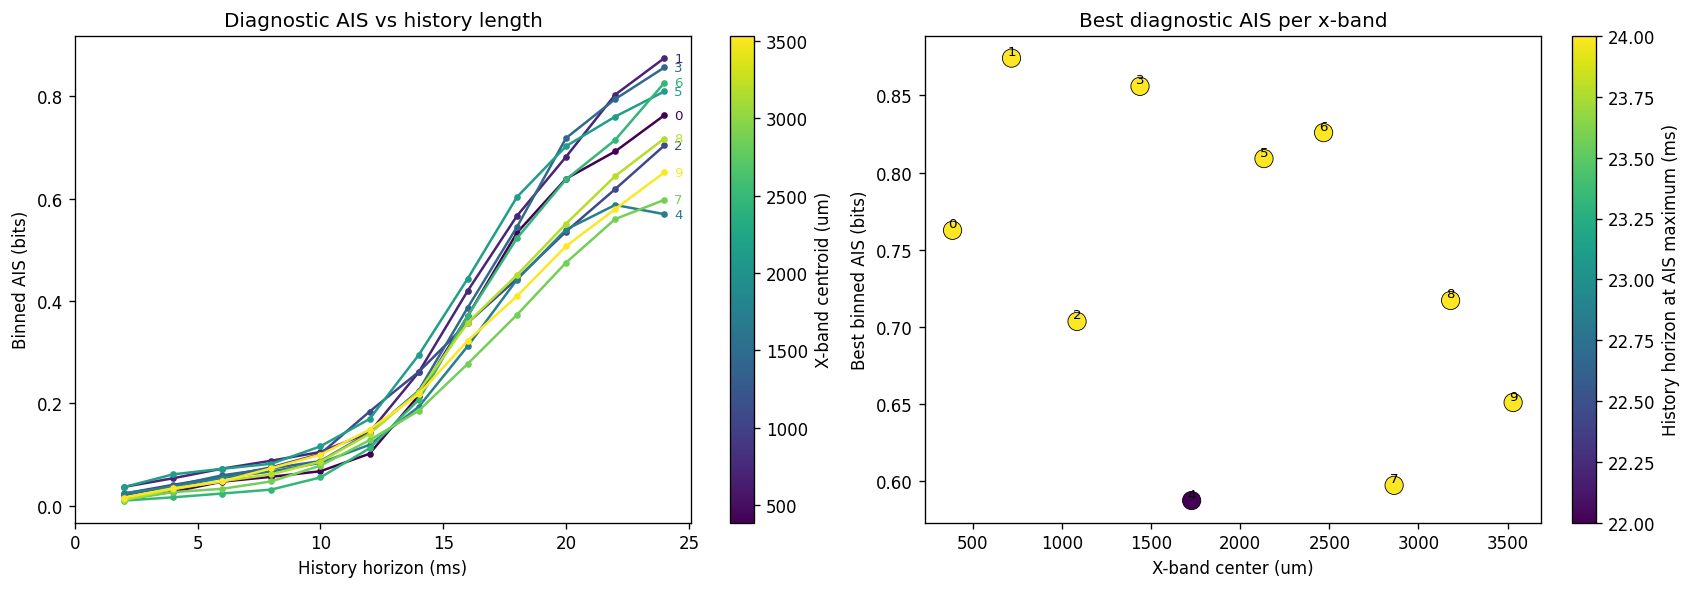

AIS diagnostic bin width: 2.0 ms
AIS diagnostic max history: 12 bins


,node_label,history_bins,history_ms,ais_bits,n_samples,x_center_um,n_gamma_spikes
0,x_band_0,12,24.0,0.762591,501,385.372340,1086
1,x_band_1,12,24.0,0.874138,501,716.203704,730
2,x_band_2,12,24.0,0.703569,501,1084.027778,1020
3,x_band_3,12,24.0,0.855853,501,1437.282609,654
4,x_band_4,11,22.0,0.587550,525,1727.115385,276
5,x_band_5,12,24.0,0.809056,501,2133.055556,504
6,x_band_6,12,24.0,0.825861,501,2467.500000,842
7,x_band_7,12,24.0,0.597410,501,2863.269231,1228
8,x_band_8,12,24.0,0.717144,501,3180.333333,1068
9,x_band_9,12,24.0,0.651051,501,3531.158537,1250


In [13]:
from collections import Counter


def bin_event_train_in_windows(spike_times_s, windows_df, bin_ms):
    spike_times_s = np.asarray(spike_times_s, dtype=float)
    bin_s = float(bin_ms) / 1000.0
    binned_windows = []
    for row in windows_df.itertuples(index=False):
        start_s = float(row.start_s)
        stop_s = float(row.stop_s)
        if stop_s <= start_s:
            continue
        n_bins = int(np.ceil((stop_s - start_s) / bin_s))
        if n_bins <= 0:
            continue
        edges = start_s + np.arange(n_bins + 1, dtype=float) * bin_s
        window_spikes = spike_times_s[(spike_times_s >= start_s) & (spike_times_s < edges[-1])]
        counts, _ = np.histogram(window_spikes, bins=edges)
        binned_windows.append(counts.astype(bool))
    return binned_windows


def plugin_binary_ais(binary_windows, history_bins):
    history_bins = int(history_bins)
    if history_bins < 1:
        return np.nan, 0

    pair_counts = Counter()
    history_counts = Counter()
    current_counts = Counter()
    n_samples = 0

    for window in binary_windows:
        window = np.asarray(window, dtype=np.uint8).reshape(-1)
        if window.size <= history_bins:
            continue
        for idx in range(history_bins, window.size):
            history = tuple(int(v) for v in window[idx - history_bins:idx])
            current = int(window[idx])
            pair_counts[(history, current)] += 1
            history_counts[history] += 1
            current_counts[current] += 1
            n_samples += 1

    if n_samples == 0:
        return np.nan, 0

    ais_bits = 0.0
    for (history, current), count in pair_counts.items():
        p_hx = count / n_samples
        p_x_given_h = count / history_counts[history]
        p_x = current_counts[current] / n_samples
        if p_hx > 0.0 and p_x_given_h > 0.0 and p_x > 0.0:
            ais_bits += p_hx * np.log2(p_x_given_h / p_x)
    return ais_bits, n_samples


ais_history_rows = []
ais_binary_windows = {}
for node_label in te_active_node_labels:
    binary_windows = bin_event_train_in_windows(
        te_node_spike_times[node_label],
        gamma_windows,
        bin_ms=AIS_DIAGNOSTIC_BIN_MS,
    )
    ais_binary_windows[node_label] = binary_windows
    for history_bins in range(1, int(AIS_DIAGNOSTIC_MAX_HISTORY_BINS) + 1):
        ais_bits, n_samples = plugin_binary_ais(binary_windows, history_bins=history_bins)
        ais_history_rows.append(
            {
                'node_label': node_label,
                'history_bins': int(history_bins),
                'history_ms': float(history_bins * AIS_DIAGNOSTIC_BIN_MS),
                'ais_bits': float(ais_bits) if np.isfinite(ais_bits) else np.nan,
                'n_samples': int(n_samples),
            }
        )

te_binned_ais_history = pd.DataFrame(ais_history_rows)
te_binned_ais_best = (
    te_binned_ais_history.sort_values(['node_label', 'ais_bits', 'history_bins'], ascending=[True, False, True])
    .groupby('node_label', as_index=False)
    .first()
    .merge(te_active_node_summary[['node_label', 'x_center_um', 'n_gamma_spikes']], on='node_label', how='left')
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), constrained_layout=True)
ax0, ax1 = axes

x_norm = Normalize(
    vmin=float(te_active_node_summary['x_center_um'].min()),
    vmax=float(te_active_node_summary['x_center_um'].max()),
)
x_cmap = plt.get_cmap('viridis')

for node_label in te_active_node_labels:
    curve = te_binned_ais_history.loc[te_binned_ais_history['node_label'] == node_label].sort_values('history_bins')
    x_center = float(te_active_node_summary.loc[te_active_node_summary['node_label'] == node_label, 'x_center_um'].iloc[0])
    color = x_cmap(x_norm(x_center))
    ax0.plot(curve['history_ms'], curve['ais_bits'], marker='o', ms=3, lw=1.5, color=color)
    ax0.text(
        float(curve['history_ms'].iloc[-1]) + 0.4,
        float(curve['ais_bits'].iloc[-1]),
        node_label.replace('x_band_', ''),
        color=color,
        fontsize=8,
        va='center',
    )
ax0.set_xlabel('History horizon (ms)')
ax0.set_ylabel('Binned AIS (bits)')
ax0.set_title('Diagnostic AIS vs history length')
ax0.set_xlim(left=0)
line_cbar = plt.colorbar(plt.cm.ScalarMappable(norm=x_norm, cmap=x_cmap), ax=ax0)
line_cbar.set_label('X-band centroid (um)')

sc = ax1.scatter(
    te_binned_ais_best['x_center_um'],
    te_binned_ais_best['ais_bits'],
    c=te_binned_ais_best['history_ms'],
    cmap='viridis',
    s=120,
    edgecolor='black',
    linewidth=0.5,
)
for row in te_binned_ais_best.itertuples(index=False):
    ax1.text(float(row.x_center_um), float(row.ais_bits), row.node_label.replace('x_band_', ''), fontsize=8, ha='center', va='bottom')
ax1.set_xlabel('X-band center (um)')
ax1.set_ylabel('Best binned AIS (bits)')
ax1.set_title('Best diagnostic AIS per x-band')
cbar = plt.colorbar(sc, ax=ax1)
cbar.set_label('History horizon at AIS maximum (ms)')

plt.show()

print(f"AIS diagnostic bin width: {AIS_DIAGNOSTIC_BIN_MS:.1f} ms")
print(f"AIS diagnostic max history: {AIS_DIAGNOSTIC_MAX_HISTORY_BINS} bins")
display(te_binned_ais_best.sort_values('x_center_um').reset_index(drop=True))




## JIDT Setup

The cells below are written against a JIDT continuous-time spiking backend. If `jpype` or the JIDT jar is unavailable, the notebook will keep the preprocessing results but skip the inference cells cleanly.

In [14]:
def discover_jidt_jar():
    candidates = []
    if JIDT_JAR_PATH:
        candidates.append(Path(JIDT_JAR_PATH).expanduser())
    for env_var in JIDT_ENV_VARS:
        env_value = os.environ.get(env_var, "")
        if env_value:
            candidates.append(Path(env_value).expanduser())
    candidates.extend(Path(path) for path in JIDT_JAR_CANDIDATES)

    seen = set()
    for candidate in candidates:
        resolved = candidate.expanduser().resolve() if candidate else None
        if resolved is None or str(resolved) in seen:
            continue
        seen.add(str(resolved))
        if resolved.exists():
            return resolved
    return None


def discover_jvm_path():
    candidates = []
    if JIDT_JVM_PATH:
        candidates.append(Path(JIDT_JVM_PATH).expanduser())
    for env_var in JIDT_JVM_ENV_VARS:
        env_value = os.environ.get(env_var, "")
        if not env_value:
            continue
        base = Path(env_value).expanduser()
        candidates.extend([
            base,
            base / 'lib/server/libjvm.dylib',
            base / 'lib/jli/libjli.dylib',
            base / 'Contents/Home/lib/server/libjvm.dylib',
            base / 'Contents/Home/lib/jli/libjli.dylib',
        ])
    conda_root = Path(sys.executable).resolve().parents[1]
    candidates.extend(sorted(conda_root.glob('pkgs/openjdk-*/lib/server/libjvm.dylib')))
    candidates.extend(sorted(conda_root.glob('pkgs/openjdk-*/lib/libjli.dylib')))

    seen = set()
    for candidate in candidates:
        resolved = candidate.expanduser().resolve() if candidate else None
        if resolved is None or str(resolved) in seen:
            continue
        seen.add(str(resolved))
        if resolved.exists():
            return resolved
    return None


def resolve_first_jclass(jpype_module, class_candidates, *, required=True):
    if not class_candidates:
        return None, None
    errors = {}
    for class_name in class_candidates:
        try:
            return class_name, jpype_module.JClass(class_name)
        except Exception as exc:
            errors[class_name] = f"{type(exc).__name__}: {exc}"
    if not required:
        return None, None
    error_lines = ["Could not resolve any JIDT class candidate."]
    error_lines.extend(f"- {name}: {msg}" for name, msg in errors.items())
    raise RuntimeError(chr(10).join(error_lines))


te_backend = {
    "available": False,
    "reason": "",
    "jar_path": None,
    "jvm_path": None,
    "jpype": None,
    "ais_class_name": None,
    "cte_class_name": None,
    "te_class_name": None,
    "ais_class": None,
    "cte_class": None,
    "te_class": None,
}

try:
    import jpype
except Exception as exc:
    te_backend["reason"] = (
        "jpype is not installed. Install jpype1 and provide a JIDT infodynamics.jar via JIDT_JAR_PATH. "
        f"Original error: {type(exc).__name__}: {exc}"
    )
else:
    jar_path = discover_jidt_jar()
    jvm_path = discover_jvm_path()
    if jar_path is None:
        te_backend["reason"] = (
            "No JIDT jar was found. Set JIDT_JAR_PATH or place infodynamics.jar under vendor/jidt, third_party/jidt, or lib/."
        )
    elif jvm_path is None:
        te_backend["reason"] = (
            "Could not find a usable JVM library for jpype. Set JIDT_JVM_PATH or JAVA_HOME to a valid libjvm/libjli path."
        )
    else:
        try:
            if not jpype.isJVMStarted():
                jpype.startJVM(str(jvm_path), classpath=[str(jar_path)])
            ais_class_name, ais_class = resolve_first_jclass(jpype, JIDT_AIS_CLASS_CANDIDATES, required=False)
            cte_class_name, cte_class = resolve_first_jclass(jpype, JIDT_CTE_CLASS_CANDIDATES, required=True)
            te_class_name, te_class = resolve_first_jclass(jpype, JIDT_TE_CLASS_CANDIDATES, required=False)
        except Exception as exc:
            te_backend["reason"] = (
                "JIDT was found but the configured spiking class candidates did not resolve. "
                f"Original error: {type(exc).__name__}: {exc}"
            )
        else:
            te_backend.update(
                {
                    "available": cte_class is not None,
                    "reason": "",
                    "jar_path": str(jar_path),
                    "jvm_path": str(jvm_path),
                    "jpype": jpype,
                    "ais_class_name": ais_class_name,
                    "cte_class_name": cte_class_name,
                    "te_class_name": te_class_name,
                    "ais_class": ais_class,
                    "cte_class": cte_class,
                    "te_class": te_class,
                }
            )
            if ais_class is None:
                te_backend["reason"] = (
                    "JIDT spiking integration TE is available. Target self-history will be inferred with the JIDT spiking network-inference demo logic instead of a separate AIS calculator."
                )

if te_backend["available"]:
    print("JIDT backend ready")
    print(f"Jar: {te_backend['jar_path']}")
    print(f"JVM: {te_backend['jvm_path']}")
    print(f"CTE class: {te_backend['cte_class_name']}")
    print(f"TE class: {te_backend['te_class_name']}")
    if te_backend["reason"]:
        print(te_backend["reason"])
else:
    warnings.warn(te_backend["reason"])

te_backend



JIDT backend ready
Jar: /Users/danielrebbin/Documents/GitHub/ephax/vendor/jidt/infodynamics.jar
JVM: /Users/danielrebbin/opt/anaconda3/pkgs/openjdk-21.0.6-h2761308_0/lib/server/libjvm.dylib
CTE class: infodynamics.measures.spiking.integration.TransferEntropyCalculatorSpikingIntegration
TE class: infodynamics.measures.spiking.TransferEntropyCalculatorSpiking
JIDT spiking integration TE is available. Target self-history will be inferred with the JIDT spiking network-inference demo logic instead of a separate AIS calculator.


{'available': True,
 'reason': 'JIDT spiking integration TE is available. Target self-history will be inferred with the JIDT spiking network-inference demo logic instead of a separate AIS calculator.',
 'jar_path': '/Users/danielrebbin/Documents/GitHub/ephax/vendor/jidt/infodynamics.jar',
 'jvm_path': '/Users/danielrebbin/opt/anaconda3/pkgs/openjdk-21.0.6-h2761308_0/lib/server/libjvm.dylib',
 'jpype': <module 'jpype' from '/Users/danielrebbin/opt/anaconda3/lib/python3.9/site-packages/jpype/__init__.py'>,
 'ais_class_name': None,
 'cte_class_name': 'infodynamics.measures.spiking.integration.TransferEntropyCalculatorSpikingIntegration',
 'te_class_name': 'infodynamics.measures.spiking.TransferEntropyCalculatorSpiking',
 'ais_class': None,
 'cte_class': <java class 'infodynamics.measures.spiking.integration.TransferEntropyCalculatorSpikingIntegration'>,
 'te_class': <java class 'infodynamics.measures.spiking.TransferEntropyCalculatorSpiking'>}

## Shorten-Style Continuous-Time TE Helpers

These helpers implement the target-wise greedy inference structure from Shorten et al. 2025 around a thin JIDT wrapper. The backend calls are written defensively because the exact spiking API surface can differ between JIDT builds.

In [15]:
def _empty_target_history_summary():
    return pd.DataFrame(columns=["target_label", "candidate_interval", "raw_te", "surrogate_mean", "bias_corrected_te", "pvalue", "accepted"])


def _empty_edge_table():
    return pd.DataFrame(columns=[
        "target_label",
        "source_label",
        "target_history_intervals",
        "source_history_intervals",
        "raw_te",
        "surrogate_mean",
        "bias_corrected_te",
        "pvalue",
        "selected_round",
        "signed_dx_um",
    ])


def _empty_candidate_rounds():
    return pd.DataFrame(columns=[
        "target_label",
        "round_idx",
        "candidate_source_label",
        "candidate_source_interval",
        "raw_te",
        "surrogate_mean",
        "bias_corrected_te",
        "pvalue",
        "selected",
        "selection_alpha",
        "selection_mode",
    ])


def _coerce_1d_float(arr):
    return np.asarray(arr, dtype=float).reshape(-1)


class JIDTSpikingNetworkInferenceBackend:
    def __init__(self, backend_state):
        self.backend_state = backend_state
        self.jpype = backend_state["jpype"]

    def _jdouble_array(self, values):
        return self.jpype.JArray(self.jpype.JDouble)(_coerce_1d_float(values).tolist())

    def _jdouble_matrix(self, list_of_arrays):
        row_arrays = [self._jdouble_array(values) for values in list_of_arrays]
        return self.jpype.JArray(self.jpype.JArray(self.jpype.JDouble))(row_arrays)

    def _jint_array(self, values):
        return self.jpype.JArray(self.jpype.JInt)([int(v) for v in values])

    def new_calc(self):
        calc = self.backend_state["cte_class"]()
        calc.setProperty("knns", str(int(TE_K_NEIGHBOURS)))
        calc.setProperty("NUM_SAMPLES_MULTIPLIER", str(float(TE_NUM_SAMPLES_MULTIPLIER)))
        calc.setProperty("SURROGATE_NUM_SAMPLES_MULTIPLIER", str(float(TE_SURROGATE_NUM_SAMPLES_MULTIPLIER)))
        calc.setProperty("K_PERM", str(int(TE_K_PERM)))
        calc.setProperty("DO_JITTERED_SAMPLING", str(bool(TE_DO_JITTERED_SAMPLING)).lower())
        calc.setProperty("JITTERED_SAMPLING_NOISE_LEVEL", str(float(TE_JITTERED_SAMPLING_NOISE_LEVEL)))
        return calc

    def set_target_embeddings(self, calc, embedding_list):
        if embedding_list:
            calc.setProperty("DEST_PAST_INTERVALS", ",".join(str(int(v)) for v in embedding_list))
        else:
            calc.setProperty("DEST_PAST_INTERVALS", "")

    def prepare_conditional_trains(self, calc, cond_set, node_spike_times):
        cond_trains = []
        calc.clearConditionalIntervals()
        for node_label, intervals in cond_set.items():
            cond_trains.append(_coerce_1d_float(node_spike_times[node_label]))
            calc.appendConditionalIntervals(self._jint_array(intervals))
        return cond_trains

    def _extract_significance(self, sig_obj, estimate_value):
        distribution = np.asarray(sig_obj.distribution, dtype=float).reshape(-1) if hasattr(sig_obj, 'distribution') else np.array([], dtype=float)
        pvalue = float(sig_obj.pValue) if hasattr(sig_obj, 'pValue') else np.nan
        surrogate_mean = float(np.mean(distribution)) if distribution.size else np.nan
        return {
            "value": float(estimate_value),
            "distribution": distribution,
            "pvalue": pvalue,
            "surrogate_mean": surrogate_mean,
            "bias_corrected_value": float(estimate_value) - surrogate_mean if np.isfinite(surrogate_mean) else float(estimate_value),
        }

    def estimate_te(self, source_times, target_times, target_embedding_intervals, source_interval, cond_set, node_spike_times, num_surrogates):
        calc = self.new_calc()
        self.set_target_embeddings(calc, target_embedding_intervals)
        calc.setProperty("SOURCE_PAST_INTERVALS", str(int(source_interval)))
        calc.startAddObservations()
        cond_trains = self.prepare_conditional_trains(calc, cond_set, node_spike_times)
        if cond_trains:
            calc.addObservations(
                self._jdouble_array(source_times),
                self._jdouble_array(target_times),
                self._jdouble_matrix(cond_trains),
            )
        else:
            calc.addObservations(
                self._jdouble_array(source_times),
                self._jdouble_array(target_times),
            )
        calc.finaliseAddObservations()
        te_val = float(calc.computeAverageLocalOfObservations())
        sig = calc.computeSignificance(int(num_surrogates), te_val)
        return self._extract_significance(sig, te_val)


te_estimator = JIDTSpikingNetworkInferenceBackend(te_backend) if te_backend["available"] else None


def infer_target_embedding_intervals(target_label, node_spike_times, estimator, alpha, num_surrogates, max_target_history):
    target_times = _coerce_1d_float(node_spike_times[target_label])
    embedding_set = [1]
    next_interval = 2
    history_rows = []

    while next_interval <= int(max_target_history):
        result = estimator.estimate_te(
            source_times=target_times,
            target_times=target_times,
            target_embedding_intervals=embedding_set,
            source_interval=next_interval,
            cond_set={},
            node_spike_times=node_spike_times,
            num_surrogates=num_surrogates,
        )
        accepted = bool(np.isfinite(result["pvalue"]) and result["pvalue"] <= float(alpha))
        history_rows.append(
            {
                "target_label": target_label,
                "candidate_interval": int(next_interval),
                "raw_te": float(result["value"]),
                "surrogate_mean": float(result["surrogate_mean"]) if np.isfinite(result["surrogate_mean"]) else np.nan,
                "bias_corrected_te": float(result["bias_corrected_value"]),
                "pvalue": float(result["pvalue"]) if np.isfinite(result["pvalue"]) else np.nan,
                "accepted": accepted,
            }
        )
        if not accepted:
            break
        embedding_set.append(int(next_interval))
        next_interval += 1

    return embedding_set, pd.DataFrame(history_rows)


def compute_max_stat_pvalue(candidate_records, alpha):
    if not candidate_records:
        return np.nan, alpha, "empty"
    surrogate_lists = [np.asarray(record["distribution"], dtype=float).reshape(-1) for record in candidate_records if np.asarray(record["distribution"]).size > 0]
    if surrogate_lists:
        min_len = min(arr.size for arr in surrogate_lists)
        surrogate_matrix = np.vstack([arr[:min_len] for arr in surrogate_lists])
        max_surrogates = surrogate_matrix.max(axis=0)
        best_raw = float(max(candidate_records, key=lambda item: item["bias_corrected_value"])["value"])
        pvalue = float(np.mean(max_surrogates >= best_raw))
        return pvalue, alpha, "max_surrogate"
    best_p = float(min(record["pvalue"] for record in candidate_records if np.isfinite(record["pvalue"])))
    bonf_alpha = float(alpha) / max(1, len(candidate_records))
    return best_p, bonf_alpha, "bonferroni_pvalue"


def run_target_inference(target_label, node_spike_times, estimator, alpha, num_surrogates, max_target_history, max_source_history, max_num_second_intervals, node_positions):
    target_embedding_set, history_df = infer_target_embedding_intervals(
        target_label=target_label,
        node_spike_times=node_spike_times,
        estimator=estimator,
        alpha=alpha,
        num_surrogates=num_surrogates,
        max_target_history=max_target_history,
    )

    target_times = _coerce_1d_float(node_spike_times[target_label])
    cond_set = {}
    next_interval_for_each_candidate = {
        source_label: 1
        for source_label in node_spike_times
        if source_label != target_label
    }
    round_rows = []
    num_second_intervals = 0
    round_idx = 0

    while True:
        candidate_records = []
        for source_label, source_interval in next_interval_for_each_candidate.items():
            if int(source_interval) > int(max_source_history):
                continue
            source_times = _coerce_1d_float(node_spike_times[source_label])
            if source_times.size < 10:
                continue
            result = estimator.estimate_te(
                source_times=source_times,
                target_times=target_times,
                target_embedding_intervals=target_embedding_set,
                source_interval=int(source_interval),
                cond_set=cond_set,
                node_spike_times=node_spike_times,
                num_surrogates=num_surrogates,
            )
            candidate_records.append(
                {
                    "target_label": target_label,
                    "candidate_source_label": source_label,
                    "candidate_source_interval": int(source_interval),
                    **result,
                }
            )

        if not candidate_records:
            break

        candidate_records = sorted(candidate_records, key=lambda item: item["bias_corrected_value"], reverse=True)
        best = candidate_records[0]
        selection_pvalue, selection_alpha, selection_mode = compute_max_stat_pvalue(candidate_records, alpha)
        selected = np.isfinite(selection_pvalue) and selection_pvalue <= float(selection_alpha)

        for record in candidate_records:
            round_rows.append(
                {
                    "target_label": target_label,
                    "round_idx": int(round_idx),
                    "candidate_source_label": record["candidate_source_label"],
                    "candidate_source_interval": int(record["candidate_source_interval"]),
                    "raw_te": float(record["value"]),
                    "surrogate_mean": float(record["surrogate_mean"]) if np.isfinite(record["surrogate_mean"]) else np.nan,
                    "bias_corrected_te": float(record["bias_corrected_value"]),
                    "pvalue": float(record["pvalue"]) if np.isfinite(record["pvalue"]) else np.nan,
                    "selected": bool(selected and record["candidate_source_label"] == best["candidate_source_label"] and int(record["candidate_source_interval"]) == int(best["candidate_source_interval"])),
                    "selection_alpha": float(selection_alpha),
                    "selection_mode": selection_mode,
                }
            )

        if not selected:
            break

        chosen_source = best["candidate_source_label"]
        chosen_interval = int(best["candidate_source_interval"])
        cond_set.setdefault(chosen_source, []).append(chosen_interval)
        next_interval_for_each_candidate[chosen_source] = chosen_interval + 1
        if chosen_interval == 2:
            num_second_intervals += 1
        round_idx += 1
        if num_second_intervals >= int(max_num_second_intervals):
            break

    prune_rows = []
    everything_significant = False
    while not everything_significant and cond_set:
        everything_significant = True
        insignificant_sources = []
        insignificant_te = []
        for candidate_source, intervals in list(cond_set.items()):
            cond_minus_candidate = {key: list(vals) for key, vals in cond_set.items()}
            if len(cond_minus_candidate[candidate_source]) > 1:
                cond_minus_candidate[candidate_source] = cond_minus_candidate[candidate_source][:-1]
            else:
                cond_minus_candidate.pop(candidate_source)

            source_interval = int(intervals[-1])
            result = estimator.estimate_te(
                source_times=_coerce_1d_float(node_spike_times[candidate_source]),
                target_times=target_times,
                target_embedding_intervals=target_embedding_set,
                source_interval=source_interval,
                cond_set=cond_minus_candidate,
                node_spike_times=node_spike_times,
                num_surrogates=num_surrogates,
            )
            keep_edge = bool(np.isfinite(result["pvalue"]) and result["pvalue"] <= float(alpha))
            prune_rows.append(
                {
                    "target_label": target_label,
                    "source_label": candidate_source,
                    "source_interval": source_interval,
                    "raw_te": float(result["value"]),
                    "surrogate_mean": float(result["surrogate_mean"]) if np.isfinite(result["surrogate_mean"]) else np.nan,
                    "bias_corrected_te": float(result["bias_corrected_value"]),
                    "pvalue": float(result["pvalue"]) if np.isfinite(result["pvalue"]) else np.nan,
                    "kept_after_prune": keep_edge,
                }
            )
            if not keep_edge:
                everything_significant = False
                insignificant_sources.append(candidate_source)
                insignificant_te.append(float(result["value"]))

        if not everything_significant and insignificant_sources:
            remove_source = insignificant_sources[int(np.argmin(insignificant_te))]
            if len(cond_set[remove_source]) > 1:
                cond_set[remove_source] = cond_set[remove_source][:-1]
            else:
                cond_set.pop(remove_source)

    edge_rows = []
    for source_label, intervals in cond_set.items():
        source_interval = int(intervals[-1])
        cond_minus_source = {key: list(vals) for key, vals in cond_set.items() if key != source_label}
        result = estimator.estimate_te(
            source_times=_coerce_1d_float(node_spike_times[source_label]),
            target_times=target_times,
            target_embedding_intervals=target_embedding_set,
            source_interval=source_interval,
            cond_set=cond_minus_source,
            node_spike_times=node_spike_times,
            num_surrogates=num_surrogates,
        )
        edge_rows.append(
            {
                "target_label": target_label,
                "source_label": source_label,
                "target_history_intervals": tuple(int(v) for v in target_embedding_set),
                "source_history_intervals": tuple(int(v) for v in intervals),
                "raw_te": float(result["value"]),
                "surrogate_mean": float(result["surrogate_mean"]) if np.isfinite(result["surrogate_mean"]) else np.nan,
                "bias_corrected_te": float(result["bias_corrected_value"]),
                "pvalue": float(result["pvalue"]) if np.isfinite(result["pvalue"]) else np.nan,
                "selected_round": int(min(idx for idx, row in enumerate(round_rows) if row["candidate_source_label"] == source_label and row["selected"])),
                "signed_dx_um": float(node_positions[target_label] - node_positions[source_label]),
            }
        )

    return {
        "target_embedding_set": tuple(int(v) for v in target_embedding_set),
        "history_df": history_df,
        "round_df": pd.DataFrame(round_rows),
        "prune_df": pd.DataFrame(prune_rows),
        "edge_df": pd.DataFrame(edge_rows),
        "conditioning_set": {key: tuple(int(v) for v in vals) for key, vals in cond_set.items()},
    }


## Run Shorten-Style Network Inference

Run the target-wise greedy search on the active x-band nodes. If the TE backend is unavailable, the cell will leave empty placeholder tables and stop cleanly after reporting the reason.

In [16]:
node_positions = dict(zip(te_node_summary["node_label"], te_node_summary["x_center_um"]))
node_spike_times_active = {label: te_node_spike_times[label] for label in te_active_node_labels}

if not te_backend["available"]:
    print("Skipping TE inference because the JIDT backend is unavailable.")
    print(te_backend["reason"])
    te_target_history_summary = _empty_target_history_summary()
    te_candidate_rounds = _empty_candidate_rounds()
    te_prune_log = pd.DataFrame(columns=["target_label", "source_label", "source_interval", "raw_te", "surrogate_mean", "bias_corrected_te", "pvalue", "kept_after_prune"])
    te_edge_table = _empty_edge_table()
    te_conditioning_sets = {label: {} for label in te_active_node_labels}
    te_target_embedding_sets = {label: tuple() for label in te_active_node_labels}
    te_adjacency_matrix = pd.DataFrame(0.0, index=te_active_node_labels, columns=te_active_node_labels)
else:
    history_frames = []
    round_frames = []
    prune_frames = []
    edge_frames = []
    te_conditioning_sets = {}
    te_target_embedding_sets = {}

    for target_label in te_active_node_labels:
        if node_spike_times_active[target_label].size < int(TE_MIN_SPIKES_PER_NODE):
            continue
        result = run_target_inference(
            target_label=target_label,
            node_spike_times=node_spike_times_active,
            estimator=te_estimator,
            alpha=TE_ALPHA,
            num_surrogates=TE_NUM_SURROGATES,
            max_target_history=TE_MAX_TARGET_HISTORY_INTERVALS,
            max_source_history=TE_MAX_SOURCE_HISTORY_INTERVALS,
            max_num_second_intervals=TE_MAX_NUM_SECOND_INTERVALS,
            node_positions=node_positions,
        )
        history_frames.append(result["history_df"])
        if not result["round_df"].empty:
            round_frames.append(result["round_df"])
        if not result["prune_df"].empty:
            prune_frames.append(result["prune_df"])
        if not result["edge_df"].empty:
            edge_frames.append(result["edge_df"])
        te_conditioning_sets[target_label] = result["conditioning_set"]
        te_target_embedding_sets[target_label] = result["target_embedding_set"]

    te_target_history_summary = pd.concat(history_frames, ignore_index=True) if history_frames else _empty_target_history_summary()
    te_candidate_rounds = pd.concat(round_frames, ignore_index=True) if round_frames else _empty_candidate_rounds()
    te_prune_log = pd.concat(prune_frames, ignore_index=True) if prune_frames else pd.DataFrame(columns=["target_label", "source_label", "source_interval", "raw_te", "surrogate_mean", "bias_corrected_te", "pvalue", "kept_after_prune"])
    te_edge_table = pd.concat(edge_frames, ignore_index=True) if edge_frames else _empty_edge_table()
    te_adjacency_matrix = pd.DataFrame(0.0, index=te_active_node_labels, columns=te_active_node_labels)
    if not te_edge_table.empty:
        for row in te_edge_table.itertuples(index=False):
            te_adjacency_matrix.loc[row.source_label, row.target_label] = float(row.bias_corrected_te)

print(f"Active TE nodes: {len(te_active_node_labels)}")
print(f"Retained TE edges: {len(te_edge_table)}")
if te_target_embedding_sets:
    print("Target embedding sets:")
    for key, vals in te_target_embedding_sets.items():
        print(f"  {key}: {vals}")
if not te_target_history_summary.empty:
    display(te_target_history_summary.head(20))
if not te_edge_table.empty:
    display(te_edge_table.sort_values("bias_corrected_te", ascending=False).head(20))

KeyboardInterrupt: 

## AIS vs TE Target History

Compare the binned AIS diagnostic against the continuous-time JIDT self-history selection. These quantities are not on the same scale: the AIS horizon is in **milliseconds** on binned occupancy traces, while the JIDT target embedding uses **counts of past interspike intervals**. The point of this section is therefore not to equate them numerically, but to flag nodes where the binned diagnostic suggests substantial short-timescale self-history while the continuous-time target-history test still stops immediately.



In [ ]:
comparison_rows = []
for node_label in te_active_node_labels:
    target_embedding = tuple(int(v) for v in te_target_embedding_sets.get(node_label, tuple()))
    history_df = te_target_history_summary.loc[
        te_target_history_summary['target_label'] == node_label
    ].sort_values('candidate_interval')
    first_extra = history_df.loc[history_df['candidate_interval'] == 2]
    first_extra_p = float(first_extra['pvalue'].iloc[0]) if not first_extra.empty and np.isfinite(first_extra['pvalue'].iloc[0]) else np.nan
    first_extra_te = float(first_extra['bias_corrected_te'].iloc[0]) if not first_extra.empty and np.isfinite(first_extra['bias_corrected_te'].iloc[0]) else np.nan
    comparison_rows.append(
        {
            'node_label': node_label,
            'jidt_history_intervals': target_embedding,
            'jidt_history_count': int(len(target_embedding)),
            'added_self_history_interval': bool(len(target_embedding) > 1),
            'first_extra_interval_pvalue': first_extra_p,
            'first_extra_interval_bias_corrected_te': first_extra_te,
        }
    )

te_history_comparison = (
    te_binned_ais_best.merge(pd.DataFrame(comparison_rows), on='node_label', how='left')
    .sort_values('x_center_um')
    .reset_index(drop=True)
)
te_history_comparison['jidt_vs_ais_flag'] = np.where(
    (~te_history_comparison['added_self_history_interval']) & (te_history_comparison['ais_bits'] >= te_history_comparison['ais_bits'].median()),
    'AIS strong, JIDT stops at base interval',
    np.where(
        te_history_comparison['added_self_history_interval'],
        'JIDT added self-history interval(s)',
        'Both conservative / weak',
    ),
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), constrained_layout=True)
ax0, ax1 = axes

x_norm = Normalize(
    vmin=float(te_history_comparison['x_center_um'].min()),
    vmax=float(te_history_comparison['x_center_um'].max()),
)
sc0 = ax0.scatter(
    te_history_comparison['x_center_um'],
    te_history_comparison['history_ms'],
    c=te_history_comparison['ais_bits'],
    cmap='magma',
    s=130,
    edgecolor=np.where(te_history_comparison['added_self_history_interval'], 'black', 'white'),
    linewidth=1.2,
)
for row in te_history_comparison.itertuples(index=False):
    ax0.text(float(row.x_center_um), float(row.history_ms), row.node_label.replace('x_band_', ''), fontsize=8, ha='center', va='center')
ax0.set_xlabel('X-band centroid (um)')
ax0.set_ylabel('Best binned AIS horizon (ms)')
ax0.set_title('AIS-preferred history by x-band')
cbar0 = plt.colorbar(sc0, ax=ax0)
cbar0.set_label('Best binned AIS (bits)')

sc1 = ax1.scatter(
    te_history_comparison['x_center_um'],
    te_history_comparison['first_extra_interval_pvalue'],
    c=te_history_comparison['history_ms'],
    cmap='viridis',
    s=130,
    edgecolor=np.where(te_history_comparison['added_self_history_interval'], 'black', 'white'),
    linewidth=1.2,
)
ax1.axhline(float(TE_ALPHA), color='crimson', ls='--', lw=1.2, label=f'alpha={TE_ALPHA:.2f}')
for row in te_history_comparison.itertuples(index=False):
    ax1.text(float(row.x_center_um), float(row.first_extra_interval_pvalue), row.node_label.replace('x_band_', ''), fontsize=8, ha='center', va='bottom')
ax1.set_xlabel('X-band centroid (um)')
ax1.set_ylabel('JIDT p-value for adding interval 2')
ax1.set_title('Continuous-time self-history test at first extra interval')
ax1.legend(loc='upper right')
cbar1 = plt.colorbar(sc1, ax=ax1)
cbar1.set_label('Best AIS horizon (ms)')

plt.show()

display(
    te_history_comparison[[
        'node_label',
        'x_center_um',
        'ais_bits',
        'history_ms',
        'jidt_history_intervals',
        'jidt_history_count',
        'first_extra_interval_pvalue',
        'first_extra_interval_bias_corrected_te',
        'jidt_vs_ais_flag',
    ]]
)



## Visualise the TE Network

Inspect the adjacency matrix ordered by x-position, a simple x-axis network layout, and TE-strength summaries against signed x displacement.

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.8), constrained_layout=True)
ax0, ax1, ax2 = axes

if te_adjacency_matrix.empty:
    ax0.text(0.5, 0.5, "No TE adjacency available", ha="center", va="center")
    ax1.text(0.5, 0.5, "No TE edges available", ha="center", va="center")
    ax2.text(0.5, 0.5, "No TE edges available", ha="center", va="center")
    for ax in axes:
        ax.set_axis_off()
else:
    im = ax0.imshow(te_adjacency_matrix.to_numpy(dtype=float), cmap="magma", aspect="auto")
    ax0.set_xticks(np.arange(len(te_adjacency_matrix.columns)))
    ax0.set_xticklabels(te_adjacency_matrix.columns, rotation=45, ha="right")
    ax0.set_yticks(np.arange(len(te_adjacency_matrix.index)))
    ax0.set_yticklabels(te_adjacency_matrix.index)
    ax0.set_title("Bias-corrected TE adjacency")
    ax0.set_xlabel("Target node")
    ax0.set_ylabel("Source node")
    cbar = fig.colorbar(im, ax=ax0)
    cbar.set_label("Bias-corrected TE")

    active_lookup = te_node_summary.set_index("node_label").loc[te_active_node_labels].reset_index()
    x_positions = active_lookup["x_center_um"].to_numpy(dtype=float)
    node_y = np.zeros_like(x_positions)
    ax1.scatter(x_positions, node_y, s=140, color="white", edgecolor="black", zorder=3)
    for row in active_lookup.itertuples(index=False):
        ax1.text(float(row.x_center_um), 0.06, row.node_label, ha="center", va="bottom", rotation=45, fontsize=8)

    if not te_edge_table.empty:
        x_lookup = dict(zip(active_lookup["node_label"], active_lookup["x_center_um"]))
        norm = Normalize(vmin=0.0, vmax=max(float(te_edge_table["bias_corrected_te"].max()), 1e-9))
        cmap = plt.get_cmap("magma")
        for row in te_edge_table.itertuples(index=False):
            src_x = float(x_lookup[row.source_label])
            dst_x = float(x_lookup[row.target_label])
            rad = 0.25 if dst_x >= src_x else -0.25
            arrow = FancyArrowPatch(
                (src_x, 0.0),
                (dst_x, 0.0),
                arrowstyle="-|>",
                mutation_scale=12,
                lw=2.0,
                color=cmap(norm(float(row.bias_corrected_te))),
                connectionstyle=f"arc3,rad={rad}",
                alpha=0.9,
            )
            ax1.add_patch(arrow)
    ax1.set_title("Retained TE network along x")
    ax1.set_xlabel("x position (um)")
    ax1.set_yticks([])
    ax1.spines[["left", "right", "top"]].set_visible(False)

    if te_edge_table.empty:
        ax2.text(0.5, 0.5, "No retained TE edges", ha="center", va="center")
        ax2.set_axis_off()
    else:
        source_history_depth = te_edge_table["source_history_intervals"].apply(lambda vals: len(vals) if isinstance(vals, (tuple, list)) else np.nan)
        scatter = ax2.scatter(
            te_edge_table["signed_dx_um"],
            te_edge_table["bias_corrected_te"],
            c=source_history_depth,
            cmap="viridis",
            s=70,
            edgecolor="black",
            linewidth=0.4,
        )
        ax2.axvline(0.0, color="0.6", ls="--", lw=1.0)
        ax2.set_xlabel("Signed dx (target - source, um)")
        ax2.set_ylabel("Bias-corrected TE")
        ax2.set_title("Retained edges: TE vs signed x displacement")
        cbar2 = fig.colorbar(scatter, ax=ax2)
        cbar2.set_label("Source history depth")

plt.show()

if not te_edge_table.empty:
    te_edge_table.sort_values(["target_label", "bias_corrected_te"], ascending=[True, False]).head(20)


## Post-Hoc Lag Scan and Propagation Speed

For each retained TE edge, rescan TE over a small positive lag grid and use the earliest significant local maximum as the propagation-delay estimate. The resulting edge delays are then turned into signed x-direction speeds.

In [ ]:
if not te_backend["available"] or te_edge_table.empty:
    print("Skipping lag scan because either the TE backend is unavailable or no TE edges were retained.")
    te_lag_scan_table = pd.DataFrame(columns=["source_label", "target_label", "lag_ms", "raw_te", "surrogate_mean", "bias_corrected_te", "pvalue"])
    te_speed_table = pd.DataFrame(columns=["source_label", "target_label", "signed_dx_um", "delay_ms", "speed_um_per_ms", "direction"])
else:
    lag_rows = []
    speed_rows = []

    for edge_row in te_edge_table.itertuples(index=False):
        cond_set_minus_source = {
            key: tuple(vals)
            for key, vals in te_conditioning_sets.get(edge_row.target_label, {}).items()
            if key != edge_row.source_label
        }
        target_embedding_set = list(te_target_embedding_sets.get(edge_row.target_label, tuple()))
        source_interval = int(list(edge_row.source_history_intervals)[-1])
        target_times = _coerce_1d_float(node_spike_times_active[edge_row.target_label])
        source_times = _coerce_1d_float(node_spike_times_active[edge_row.source_label])

        edge_curve = []
        for lag_ms in np.asarray(TE_LAG_SCAN_MS, dtype=float):
            shifted_source = source_times + (float(lag_ms) / 1000.0)
            shifted_source = shifted_source[(shifted_source >= float(rec.start_time)) & (shifted_source <= float(rec.end_time))]
            if shifted_source.size < 10:
                continue
            result = te_estimator.estimate_te(
                source_times=shifted_source,
                target_times=target_times,
                target_embedding_intervals=target_embedding_set,
                source_interval=source_interval,
                cond_set=cond_set_minus_source,
                node_spike_times=node_spike_times_active,
                num_surrogates=TE_NUM_SURROGATES,
            )
            lag_record = {
                "source_label": edge_row.source_label,
                "target_label": edge_row.target_label,
                "lag_ms": float(lag_ms),
                "raw_te": float(result["value"]),
                "surrogate_mean": float(result["surrogate_mean"]) if np.isfinite(result["surrogate_mean"]) else np.nan,
                "bias_corrected_te": float(result["bias_corrected_value"]),
                "pvalue": float(result["pvalue"]) if np.isfinite(result["pvalue"]) else np.nan,
                "signed_dx_um": float(edge_row.signed_dx_um),
            }
            lag_rows.append(lag_record)
            edge_curve.append(lag_record)

        edge_curve_df = pd.DataFrame(edge_curve).sort_values("lag_ms")
        if edge_curve_df.empty:
            continue
        significant_mask = edge_curve_df["pvalue"].to_numpy(dtype=float) <= float(TE_ALPHA)
        if not np.any(significant_mask):
            continue

        values = edge_curve_df["bias_corrected_te"].to_numpy(dtype=float)
        peaks, _ = find_peaks(values)
        peak_mask = np.zeros(values.shape, dtype=bool)
        if peaks.size:
            peak_mask[peaks] = True
        eligible = edge_curve_df.loc[significant_mask & peak_mask].copy()
        if eligible.empty:
            eligible = edge_curve_df.loc[significant_mask].copy()
        eligible = eligible.sort_values(["lag_ms", "bias_corrected_te"], ascending=[True, False])
        best_delay = eligible.iloc[0]

        delay_ms = float(best_delay["lag_ms"])
        signed_dx_um = float(best_delay["signed_dx_um"])
        speed_um_per_ms = signed_dx_um / delay_ms if delay_ms > 0 else np.nan
        direction = "left_to_right" if signed_dx_um > 0 else "right_to_left" if signed_dx_um < 0 else "zero_dx"
        speed_rows.append(
            {
                "source_label": edge_row.source_label,
                "target_label": edge_row.target_label,
                "signed_dx_um": signed_dx_um,
                "delay_ms": delay_ms,
                "speed_um_per_ms": speed_um_per_ms,
                "direction": direction,
            }
        )

    te_lag_scan_table = pd.DataFrame(lag_rows)
    te_speed_table = pd.DataFrame(speed_rows)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), constrained_layout=True)
ax0, ax1 = axes

if te_lag_scan_table.empty:
    ax0.text(0.5, 0.5, "No lag scans available", ha="center", va="center")
    ax0.set_axis_off()
else:
    edge_strength = te_edge_table.sort_values("bias_corrected_te", ascending=False)[["source_label", "target_label"]].head(6)
    for row in edge_strength.itertuples(index=False):
        edge_curve = te_lag_scan_table.loc[
            (te_lag_scan_table["source_label"] == row.source_label)
            & (te_lag_scan_table["target_label"] == row.target_label)
        ].sort_values("lag_ms")
        if edge_curve.empty:
            continue
        ax0.plot(edge_curve["lag_ms"], edge_curve["bias_corrected_te"], lw=1.8, label=f"{row.source_label} -> {row.target_label}")
    ax0.set_xlabel("Scanned source lead lag (ms)")
    ax0.set_ylabel("Bias-corrected TE")
    ax0.set_title("Top retained edges: lag scans")
    ax0.legend(loc="best", fontsize=8)

if te_speed_table.empty:
    ax1.text(0.5, 0.5, "No delay-derived speeds available", ha="center", va="center")
    ax1.set_axis_off()
else:
    colors = te_speed_table["direction"].map({"left_to_right": "tab:blue", "right_to_left": "tab:orange", "zero_dx": "0.5"}).to_numpy()
    ax1.scatter(np.abs(te_speed_table["signed_dx_um"]), te_speed_table["delay_ms"], c=colors, s=70, edgecolor="black", linewidth=0.4)
    valid_fit = te_speed_table[["signed_dx_um", "delay_ms"]].dropna()
    valid_fit = valid_fit.loc[valid_fit["delay_ms"] > 0]
    if len(valid_fit) >= 2:
        x = np.abs(valid_fit["signed_dx_um"].to_numpy(dtype=float))
        y = valid_fit["delay_ms"].to_numpy(dtype=float)
        slope, intercept = np.polyfit(x, y, deg=1)
        x_line = np.linspace(x.min(), x.max(), 100)
        ax1.plot(x_line, intercept + slope * x_line, color="black", ls="--", lw=1.5, label=f"delay fit: y={slope:.4f}x+{intercept:.2f}")
        ax1.legend(loc="upper left")
    ax1.set_xlabel("|signed dx| (um)")
    ax1.set_ylabel("Delay (ms)")
    ax1.set_title("Delay vs x displacement on retained edges")

plt.show()

if not te_speed_table.empty:
    speed_summary = te_speed_table.groupby("direction", dropna=False)["speed_um_per_ms"].agg(["count", "median", "mean"]).reset_index()
    display(speed_summary)
    display(te_speed_table.sort_values("delay_ms").head(20))

## Notes

This notebook is intentionally notebook-local. Once the JIDT-backed inference workflow is stable here, the data-prep and estimator wrappers can be moved into the main library.